# Coastal Shoreline Threshold Research Notebook

**Location:** Waskaduwa Beach, Kalutara, Sri Lanka
**Period:** 2012 – 2024 (12 monsoon-year intervals)

**Objective:** Learn shoreline-response threshold ranges from **filename-defined shoreline intervals** and **monthly wave, wind, and current patterns**, then forecast **future erosion-side and accretion-side threshold ranges directly** from historical threshold trajectories.

## Core Workflow

1. **Monthly Dataset Conversion** — Convert Wave, Wind, and Current NetCDFs to a consistent monthly forcing table.
2. **DSAS Transect → Year Labels** — Build three-class shoreline interval labels using the CSV file name year as the correct annual key.
3. **Three-Class Shoreline Target** — Keep `erosion` (NSM ≤ −1 m), `stable` (|NSM| < 1 m), and `accretion` (NSM ≥ +1 m) as the ordered shoreline response classes.
4. **Monthly Pattern Signatures** — Extract within-interval monthly forcing anomaly features per shoreline interval (full April–March monsoon year).
5. **Three-Class Pattern Recognition** — Screen and train ordered and multiclass models on the monthly pattern signatures using Leave-One-Out cross-validation.
6. **Threshold Range Estimation** — Estimate two boundary thresholds per driver: `erosion_onset`, `accretion_onset`, with bootstrap confidence intervals.
7. **Direct Threshold Forecasting** — Forecast threshold trajectories themselves 24 months ahead (H6, H12, H18, H24) using TheilSen regression on the historical threshold history.

## Data Inputs

1. **DSAS Shoreline CSVs** — Transect-based shoreline statistics from the QGIS/DSAS workflow. File names are the authoritative interval years.
2. **Wave NetCDF** — Monthly wave forcing variables (VHM0, VTPK, VMDR, VSDX, VSDY).
3. **Wind NetCDF** — Monthly sea-surface wind forcing variables (wind_speed, eastward_wind, northward_wind).
4. **Current NetCDF** — Monthly ocean-current forcing variables (uo, vo, zos).

## Research Note

If a shoreline class is absent in the historical annual labels, the notebook keeps that class in the ordered framework but reports the corresponding thresholds as unsupported rather than inventing values.


## Section 0 — Environment Setup & Data Loading

Import all required libraries and load the four datasets that drive the entire analysis.

**Data inputs:**
1. **DSAS Shoreline CSVs** (`notebook_data/*-stat.csv`) — Transect NSM/EPR statistics from QGIS, one file per year-pair interval (12 files, 2012–2024)
2. **Wave NetCDF** — Global Ocean Waves Reanalysis 2009–2024 (VHM0, VTPK, VMDR, VSDX, VSDY)
3. **Wind NetCDF** — Sea Surface Wind & Stress from Scatterometer 2009–2024 (wind_speed, eastward_wind, northward_wind)
4. **Current NetCDF** — Global Ocean Physics Reanalysis 2009–2024 (uo, vo, zos)


In [1]:
# =============================================================================
# Section 0.1 — Import All Required Libraries
# =============================================================================
# All imports are consolidated here so every section below can run cleanly.
# Libraries from older binary-workflow code have been removed.

# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings
from pathlib import Path
from datetime import datetime

# ── Numeric and data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import xarray as xr                     # reading NetCDF datasets (wave, wind, current)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Statistical tests ─────────────────────────────────────────────────────────
# scipy.stats   — used in bootstrap CI (Section 1)
# kruskal       — Kruskal-Wallis feature screening (Section 3.2)
# spearmanr     — Spearman rank correlation for ordered screening (Section 3.2)
from scipy import stats
from scipy.stats import kruskal, spearmanr

# ── Scikit-learn: pattern recognition + threshold forecasting ─────────────────
from sklearn.ensemble import RandomForestClassifier      # Section 3.2
from sklearn.linear_model import (
    LogisticRegression,      # Section 3.2 — multinomial softmax baseline
    TheilSenRegressor,       # Section 3.4 — robust trend for threshold forecasting
)
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import LeaveOneOut          # Section 3.2 — LOOCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif  # Section 3.2 — MI screening

# ── Statsmodels: ordered logit for threshold boundary estimation (Section 3.3) ─
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.tools.sm_exceptions import ConvergenceWarning, HessianInversionWarning

# Suppress convergence/inversion warnings from ordered logit fitting
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=HessianInversionWarning)
warnings.filterwarnings('ignore')

# ── Output directories ────────────────────────────────────────────────────────
os.makedirs('./figures', exist_ok=True)
os.makedirs('./outputs', exist_ok=True)

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

print("✓ Libraries loaded")


✓ Libraries loaded


In [2]:
# =============================================================================
# Section 0.2 — Load all datasets
# =============================================================================

from pathlib import Path

DATA_PATH = Path("notebook_data")
SHORELINE_GLOB = "*-stat.csv"
WAVE_FILE = DATA_PATH / "Global_Ocean_Waves_Reanalysis_2009_2024.nc"
WIND_FILE = DATA_PATH / "Global Ocean Monthly Mean Sea Surface Wind and Stress from Scatterometer and Model_2009_2024.nc"
CURRENT_FILE = DATA_PATH / "Global Ocean Physics Reanalysis(current_data)_2009_2024.nc"


def parse_interval_from_filename(path_obj):
    start_token, end_token = path_obj.stem.replace("-stat", "").split("-")
    return 2000 + int(start_token), 2000 + int(end_token)


shoreline_interval_files = sorted(DATA_PATH.glob(SHORELINE_GLOB))
if not shoreline_interval_files:
    raise FileNotFoundError(f"No shoreline interval files matched {SHORELINE_GLOB!r} in {DATA_PATH}")

shoreline_interval_tables = {}
inventory_rows = []

for path_obj in shoreline_interval_files:
    start_year, end_year = parse_interval_from_filename(path_obj)
    interval_label = f"{start_year}-{end_year}"
    interval_df = pd.read_csv(path_obj)
    shoreline_interval_tables[interval_label] = interval_df

    metadata_years = sorted(
        set(interval_df['SCE_closest_year'].dropna().astype(int)).union(
            set(interval_df['SCE_farthest_year'].dropna().astype(int))
        )
    )
    inventory_rows.append({
        'interval': interval_label,
        # Year key = END year of the interval (e.g. 12-13-stat.csv → 2013)
        'monsoon_year': end_year,
        'interval_start': start_year,
        'interval_end': end_year,
        'n_transects': len(interval_df),
        'metadata_years': ', '.join(map(str, metadata_years)),
        'metadata_matches_filename': metadata_years == [start_year, end_year],
        'NSM_unc': float(interval_df['NSM_highest_unc'].median()),
        'EPR_unc': float(interval_df['EPR_unc'].median()),
    })

shoreline_inventory = pd.DataFrame(inventory_rows).sort_values('monsoon_year').reset_index(drop=True)
latest_interval_label = shoreline_inventory.iloc[-1]['interval']

print("=" * 60)
print("SHORELINE DATA INVENTORY")
print("=" * 60)
print(f"Files loaded  : {len(shoreline_interval_files)}")
print(f"Year range    : {shoreline_inventory.iloc[0]['interval']} → {shoreline_inventory.iloc[-1]['interval']}")
print("Year key rule : END year of each interval  (12-13-stat.csv → year 2013)")

metadata_mismatch_count = int((~shoreline_inventory['metadata_matches_filename']).sum())
if metadata_mismatch_count > 0:
    print(
        f"Warning: {metadata_mismatch_count} files have internal DSAS year stamps that do not match the file name. "
        "The file name interval will be used for year-wise aggregation."
    )

display(shoreline_inventory)

# ── Load NetCDF datasets ──
wave_ds = xr.open_dataset(WAVE_FILE)
wind_ds = xr.open_dataset(WIND_FILE)
current_ds = xr.open_dataset(CURRENT_FILE)

for name, ds in [('Wave', wave_ds), ('Wind', wind_ds), ('Current', current_ds)]:

    print(f"\n{name}: {list(ds.data_vars)} | time {ds.sizes.get('time', '?')} steps")

SHORELINE DATA INVENTORY
Files loaded  : 12
Year range    : 2012-2013 → 2023-2024
Year key rule : END year of each interval  (12-13-stat.csv → year 2013)


,interval,monsoon_year,interval_start,interval_end,n_transects,metadata_years,metadata_matches_filename,NSM_unc,EPR_unc
0,2012-2013,2013,2012,2013,162,"2012, 2013",True,2.0,4.22
1,2013-2014,2014,2013,2014,164,"2014, 2015",False,2.0,4.29
2,2014-2015,2015,2014,2015,158,"2014, 2015",True,2.0,3.11
3,2015-2016,2016,2015,2016,159,"2015, 2016",True,2.0,2.26
4,2016-2017,2017,2016,2017,163,"2016, 2018",False,2.0,1.69
5,2017-2018,2018,2017,2018,162,"2018, 2019",False,2.0,3.07
6,2018-2019,2019,2018,2019,161,2019,False,2.0,5.77
7,2019-2020,2020,2019,2020,160,"2019, 2021",False,2.0,2.42
8,2020-2021,2021,2020,2021,164,"2021, 2022",False,2.0,2.11
9,2021-2022,2022,2021,2022,163,"2021, 2022",True,2.0,2.11



Wave: ['VHM0', 'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW', 'VMDR', 'VMDR_SW1', 'VMDR_SW2', 'VMDR_WW', 'VPED', 'VSDX', 'VSDY', 'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW', 'VTM02', 'VTM10', 'VTPK'] | time 35033 steps

Wind: ['eastward_stress', 'eastward_stress_bias', 'eastward_stress_sdd', 'eastward_wind', 'eastward_wind_bias', 'eastward_wind_sdd', 'northward_stress', 'northward_stress_bias', 'northward_stress_sdd', 'northward_wind', 'northward_wind_bias', 'northward_wind_sdd', 'number_of_observations', 'wind_speed', 'wind_speed_bias', 'wind_speed_sdd', 'wind_stress_magnitude', 'wind_stress_magnitude_bias', 'wind_stress_magnitude_sdd'] | time 156 steps

Current: ['bottomT', 'mlotst', 'siconc', 'sithick', 'so', 'thetao', 'uo', 'usi', 'vo', 'vsi', 'zos'] | time 146 steps


### Section 0.3 — Dataset Variable Dictionary

This cell inspects all three oceanographic NetCDF datasets and displays each variable's **name**, **long name (meaning)**, **units**, and **shape**, providing a complete reference for the data used in this analysis.

In [3]:
# =============================================================================
# Section 0.3 — Dataset Variable Dictionary
# ============================================================================= 

# Reuse wave_ds, wind_ds, current_ds already loaded in Section 0.2

def inspect_dataset(ds, dataset_name):
    """Extract variable metadata from an xarray Dataset."""
    rows = []
    for var_name in sorted(ds.data_vars):
        v = ds[var_name]
        long_name = v.attrs.get('long_name', v.attrs.get('standard_name', 'N/A'))
        units = v.attrs.get('units', 'N/A')
        shape = dict(zip(v.dims, v.shape))
        rows.append({
            'Variable': var_name,
            'Description': long_name,
            'Units': units,
            'Dimensions': str(shape)
        })
    df = pd.DataFrame(rows)
    print("=" * 90)
    print(f"  {dataset_name}")
    print(f"  Source: {ds.attrs.get('source', ds.attrs.get('institution', 'N/A'))}")
    print(f"  Time range: {str(ds.time.values[0])[:10]} — {str(ds.time.values[-1])[:10]}")
    print(f"  Total variables: {len(ds.data_vars)}")
    print("=" * 90)
    display(df)
    print()
    return df

print("\n📋 OCEANOGRAPHIC DATASET VARIABLE DICTIONARY\n")

wave_var_info    = inspect_dataset(wave_ds,    "🌊 WAVE DATASET — Global Ocean Waves Reanalysis")
wind_var_info    = inspect_dataset(wind_ds,    "💨 WIND DATASET — Global Ocean Surface Wind & Stress")
current_var_info = inspect_dataset(current_ds, "🌀 CURRENT DATASET — Global Ocean Physics Reanalysis")


📋 OCEANOGRAPHIC DATASET VARIABLE DICTIONARY

  🌊 WAVE DATASET — Global Ocean Waves Reanalysis
  Source: METEO-FRANCE
  Time range: 2013-01-01 — 2024-12-28
  Total variables: 17


,Variable,Description,Units,Dimensions
0,VHM0,Spectral significant wave height (Hm0),m,"{'time': 35033, 'latitude': 1, 'longitude': 1}"
1,VHM0_SW1,Spectral significant primary swell wave height,m,"{'time': 35033, 'latitude': 1, 'longitude': 1}"
2,VHM0_SW2,Spectral significant secondary swell wave height,m,"{'time': 35033, 'latitude': 1, 'longitude': 1}"
3,VHM0_WW,Spectral significant wind wave height,m,"{'time': 35033, 'latitude': 1, 'longitude': 1}"
4,VMDR,Mean wave direction from (Mdir),degree,"{'time': 35033, 'latitude': 1, 'longitude': 1}"
5,VMDR_SW1,Mean primary swell wave direction from,degree,"{'time': 35033, 'latitude': 1, 'longitude': 1}"
6,VMDR_SW2,Mean secondary swell wave direction from,degree,"{'time': 35033, 'latitude': 1, 'longitude': 1}"
7,VMDR_WW,Mean wind wave direction from,degree,"{'time': 35033, 'latitude': 1, 'longitude': 1}"
8,VPED,Wave principal direction at spectral peak,degree,"{'time': 35033, 'latitude': 1, 'longitude': 1}"
9,VSDX,Stokes drift U,m s-1,"{'time': 35033, 'latitude': 1, 'longitude': 1}"



  💨 WIND DATASET — Global Ocean Surface Wind & Stress
  Source: Royal Netherlands Meteorological Institute (KNMI)
  Time range: 2012-01-01 — 2024-12-01
  Total variables: 19


,Variable,Description,Units,Dimensions
0,eastward_stress,Surface wind stress eastward component,N m-2,"{'time': 156, 'latitude': 1, 'longitude': 1}"
1,eastward_stress_bias,Scatterometer-model bias of surface wind stres...,N m-2,"{'time': 156, 'latitude': 1, 'longitude': 1}"
2,eastward_stress_sdd,Standard deviation of differences of surface w...,N m-2,"{'time': 156, 'latitude': 1, 'longitude': 1}"
3,eastward_wind,Stress-equivalent wind eastward component at 10 m,m s-1,"{'time': 156, 'latitude': 1, 'longitude': 1}"
4,eastward_wind_bias,Scatterometer-model bias of stress-equivalent ...,m s-1,"{'time': 156, 'latitude': 1, 'longitude': 1}"
5,eastward_wind_sdd,Standard deviation of differences of stress-eq...,m s-1,"{'time': 156, 'latitude': 1, 'longitude': 1}"
6,northward_stress,Surface wind stress northward component,N m-2,"{'time': 156, 'latitude': 1, 'longitude': 1}"
7,northward_stress_bias,Scatterometer-model bias of surface wind stres...,N m-2,"{'time': 156, 'latitude': 1, 'longitude': 1}"
8,northward_stress_sdd,Standard deviation of differences of surface w...,N m-2,"{'time': 156, 'latitude': 1, 'longitude': 1}"
9,northward_wind,Stress-equivalent wind northward component at ...,m s-1,"{'time': 156, 'latitude': 1, 'longitude': 1}"



  🌀 CURRENT DATASET — Global Ocean Physics Reanalysis
  Source: MERCATOR GLORYS12V1
  Time range: 2012-02-01 — 2024-03-01
  Total variables: 11


,Variable,Description,Units,Dimensions
0,bottomT,Sea floor potential temperature,degrees_C,"{'time': 146, 'latitude': 1, 'longitude': 1}"
1,mlotst,Density ocean mixed layer thickness,m,"{'time': 146, 'latitude': 1, 'longitude': 1}"
2,siconc,Ice concentration,1,"{'time': 146, 'latitude': 1, 'longitude': 1}"
3,sithick,Sea ice thickness,m,"{'time': 146, 'latitude': 1, 'longitude': 1}"
4,so,Salinity,1e-3,"{'time': 146, 'depth': 1, 'latitude': 1, 'long..."
5,thetao,Temperature,degrees_C,"{'time': 146, 'depth': 1, 'latitude': 1, 'long..."
6,uo,Eastward velocity,m s-1,"{'time': 146, 'depth': 1, 'latitude': 1, 'long..."
7,usi,Sea ice eastward velocity,m s-1,"{'time': 146, 'latitude': 1, 'longitude': 1}"
8,vo,Northward velocity,m s-1,"{'time': 146, 'depth': 1, 'latitude': 1, 'long..."
9,vsi,Sea ice northward velocity,m s-1,"{'time': 146, 'latitude': 1, 'longitude': 1}"


In [4]:
# =============================================================================
# Section 0.4 — Validate Required Variables & Data Quality
# =============================================================================
import numpy as np

required_vars = {
    "🌊 Wave Dataset": {
        "dataset": wave_ds,
        "variables": ["VHM0", "VMDR", "VSDX", "VSDY", "VTPK"]
    },
    "💨 Wind Dataset": {
        "dataset": wind_ds,
        "variables": ["eastward_wind", "northward_wind", "wind_speed"]
    },
    "🌀 Current Dataset": {
        "dataset": current_ds,
        "variables": ["uo", "vo", "zos"]
    }
}

print("=" * 100)
print("  DATASET VARIABLE VALIDATION & DATA QUALITY CHECK")
print("=" * 100)

all_valid = True
for ds_name, info in required_vars.items():
    ds = info["dataset"]
    available = list(ds.data_vars)
    print(f"\n{ds_name}")
    print(f"  Available variables: {available}")
    header = f"  {'Variable':<20} {'Status':<12} {'Total':<10} {'Valid':<10} {'NaN/Null':<10} {'NaN %':<8} {'Min':<12} {'Max':<12} {'Mean':<12}"
    print(header)
    print(f"  {'-'*118}")
    for var in info["variables"]:
        if var in available:
            v = ds[var]
            vals = v.values.flatten()
            total = len(vals)
            nan_count = int(np.isnan(vals).sum())
            valid_count = total - nan_count
            nan_pct = (nan_count / total * 100) if total > 0 else 0
            valid_vals = vals[~np.isnan(vals)]
            if len(valid_vals) > 0:
                v_min = f"{np.nanmin(valid_vals):.4f}"
                v_max = f"{np.nanmax(valid_vals):.4f}"
                v_mean = f"{np.nanmean(valid_vals):.4f}"
            else:
                v_min = v_max = v_mean = "—"
            status = "✅ Good" if nan_pct < 50 else "⚠️ Sparse" if nan_pct < 100 else "❌ Empty"
            if nan_pct > 0 and nan_pct < 100:
                status = f"⚠️ {nan_pct:.1f}%null"
            elif nan_pct >= 100:
                status = "❌ AllNull"
                all_valid = False
            else:
                status = "✅ Good"
            print(f"  {var:<20} {status:<12} {total:<10} {valid_count:<10} {nan_count:<10} {nan_pct:<8.1f} {v_min:<12} {v_max:<12} {v_mean:<12}")
        else:
            print(f"  {var:<20} {'❌ Missing':<12} {'—':<10} {'—':<10} {'—':<10} {'—':<8} {'—':<12} {'—':<12} {'—':<12}")
            all_valid = False

print("\n" + "=" * 100)
if all_valid:
    print("  ✅ All required variables are present with valid data.")
else:
    print("  ⚠️  Some variables are MISSING or contain ALL null values — check dataset files.")
print("=" * 100)

  DATASET VARIABLE VALIDATION & DATA QUALITY CHECK

🌊 Wave Dataset
  Available variables: ['VHM0', 'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW', 'VMDR', 'VMDR_SW1', 'VMDR_SW2', 'VMDR_WW', 'VPED', 'VSDX', 'VSDY', 'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW', 'VTM02', 'VTM10', 'VTPK']
  Variable             Status       Total      Valid      NaN/Null   NaN %    Min          Max          Mean        
  ----------------------------------------------------------------------------------------------------------------------
  VHM0                 ✅ Good       35033      35033      0          0.0      0.4000       3.5600       1.1765      
  VMDR                 ✅ Good       35033      35033      0          0.0      170.9100     326.4300     218.5606    
  VSDX                 ✅ Good       35033      35033      0          0.0      -0.0500      0.1600       0.0291      
  VSDY                 ✅ Good       35033      35033      0          0.0      -0.0900      0.1700       0.0063      
  VTPK                 ✅ Good

## Section 1 — DSAS Year-Pair Classification to Research-Grade Annual Labels

This section converts the uploaded **year-pair DSAS transect files** into **annual coastal change labels**.

**Year key convention**  
The **end year** of each file name is used as the annual key:  
`12-13-stat.csv → year 2013`,  `13-14-stat.csv → year 2014`, …  `23-24-stat.csv → year 2024`.  
This labels each observation by the year in which the shoreline state was measured.

**Statistical labeling pipeline (4 stages)**

| Stage | Method | Purpose |
|-------|--------|---------|
| 1 — Per-transect | Uncertainty-aware NSM ± NSM_highest_unc · EPR direction check | Conservative per-point classification |
| 2 — Robust estimate | 10% trimmed mean · Hodges-Lehmann pseudo-median · Bootstrap 95% CI (2 000 resamples) | Resistant to outlier transects |
| 3 — Significance gate | Wilcoxon signed-rank test vs 0 (p < 0.05) · Rank-biserial |r| ≥ 0.30 | Only classify if the shift is statistically real and practically meaningful |
| 4 — Class assignment | Both bootstrap CI bounds must lie entirely within the class zone | Prevents threshold-straddling misclassification |

**Three-class boundaries (annual NSM)**

| Class | Rule | Interpretation |
|-------|------|----------------|

| `erosion` | 95% CI entirely below −1 m | Persistent retreat |
| `stable` | CI overlaps 0 m **or** significance gate fails | Within measurement noise / no clear signal |
| `accretion` | 95% CI entirely above +1 m | Persistent advance |



In [5]:
# =============================================================================
# Section 1.1 — DSAS Year-Pair Transect Files → 3-Class Annual Shoreline Labels
# =============================================================================
# Year key = END year of each CSV (e.g. 12-13-stat.csv → year 2013).
#
# FOUR-STAGE STATISTICAL LABELING PIPELINE
# ─────────────────────────────────────────
# Stage 1 — Per-transect classification
#   Uncertainty-aware NSM class: compare NSM ± NSM_highest_unc to thresholds.
#   EPR direction consistency: if EPR sign (accounting for ± EPR_unc) contradicts
#   the NSM class direction, step the class one level toward 'stable'.
#
# Stage 2 — Robust interval-level estimation
#   • 10% trimmed mean  (outlier-resistant point estimate of net change)
#   • Hodges-Lehmann pseudo-median  (median of all pairwise averages (xi+xj)/2;
#     most robust location estimator for symmetric distributions)
#   • Bootstrap 95% CI on trimmed mean (2 000 resamples, fixed seed)
#
# Stage 3 — Significance gate  [BOTH must pass to assign a non-stable class]
#   • Wilcoxon signed-rank test vs 0: non-parametric, no normality needed.
#     Tests whether the population of NSM values is significantly shifted from
#     the zero (no-change) baseline.  Threshold: p < 0.05.
#   • Rank-biserial correlation r as effect size.
#     r = (W⁺ − W⁻) / (n(n+1)/2);  |r| ≥ 0.30 = medium practical effect.
#
# Stage 4 — CI-based class assignment
#   Both 95% CI bounds must be entirely within the class zone:
#     erosion   → entire CI below −1 m
#     accretion → entire CI above +1 m
#   Transitional (CI straddles a threshold): transect majority vote.
#   Ambiguous or non-significant: 'stable'.
# =============================================================================

from scipy.stats import wilcoxon as _wilcoxon_scipy

# ── NSM class boundaries ──────────────────────────────────────────────────────
EROSION_THRESHOLD   = -1.0
ACCRETION_THRESHOLD =  1.0

TRIM_FRACTION     = 0.10
BOOTSTRAP_SAMPLES = 2000
BOOTSTRAP_SEED    = 42

# Significance gates (Stage 3)
WILCOXON_ALPHA  = 0.05    # p < 0.05 required
EFFECT_SIZE_MIN = 0.30    # |rank-biserial r| ≥ 0.30 required

CLASS_SCORE_MAP = {
    'erosion': -1, 'stable': 0, 'accretion': 1,
}
SCORE_CLASS_MAP = {score: label for label, score in CLASS_SCORE_MAP.items()}


# ── Stage 1 helpers ───────────────────────────────────────────────────────────

def classify_nsm_raw(nsm):
    """Classify a single NSM value (no uncertainty adjustment)."""
    if nsm <= EROSION_THRESHOLD:   return 'erosion'
    if nsm < ACCRETION_THRESHOLD:  return 'stable'
    return 'accretion'


def classify_with_uncertainty(value, uncertainty):
    """
    Classify NSM using ± uncertainty band.
    Conservative rule: a class is only assigned if the ENTIRE uncertainty
    band lies within that class zone.  Otherwise → 'stable'.
    """
    unc = 0.0 if pd.isna(uncertainty) else float(uncertainty)
    lower, upper = value - unc, value + unc
    if upper <= EROSION_THRESHOLD:   return 'erosion'
    if lower >= ACCRETION_THRESHOLD: return 'accretion'
    return 'stable'


def direction_with_uncertainty(value, uncertainty):
    """Return −1 (retreat), +1 (advance), or 0 (uncertain) after ± unc."""
    unc = 0.0 if pd.isna(uncertainty) else float(uncertainty)
    if value + unc < 0: return -1
    if value - unc > 0: return  1
    return 0


def _step_toward_stable(label):
    score = CLASS_SCORE_MAP[label]
    return SCORE_CLASS_MAP[int(score - np.sign(score))] if score != 0 else label


def consensus_transect_class(row):
    """
    Combine uncertainty-adjusted NSM class with EPR direction.
    If EPR direction contradicts NSM or is uncertain → step toward stable.
    """
    base_class    = classify_with_uncertainty(row['NSM'], row.get('NSM_highest_unc', 0.0))
    base_score    = CLASS_SCORE_MAP[base_class]
    if base_score == 0:
        return base_class
    epr_dir       = direction_with_uncertainty(row['EPR'], row.get('EPR_unc', 0.0))
    base_dir      = 1 if base_score > 0 else -1
    if epr_dir == 0:             return _step_toward_stable(base_class)
    if epr_dir != base_dir:      return 'stable'
    return base_class


# ── Stage 2 helpers ───────────────────────────────────────────────────────────

def _trimmed_mean(values, proportion=TRIM_FRACTION):
    arr = np.sort(np.asarray(values, dtype=float))
    arr = arr[np.isfinite(arr)]
    if arr.size == 0: return np.nan
    k = int(np.floor(arr.size * proportion))
    return float(arr.mean() if 2 * k >= arr.size else arr[k:arr.size - k].mean())


def _bootstrap_ci(values, n_boot=BOOTSTRAP_SAMPLES, proportion=TRIM_FRACTION, seed=BOOTSTRAP_SEED):
    """Bootstrap 95% CI on the 10% trimmed mean of NSM values."""
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0: return np.nan, np.nan
    rng  = np.random.default_rng(seed)
    boot = [
        _trimmed_mean(rng.choice(arr, size=arr.size, replace=True), proportion)
        for _ in range(n_boot)
    ]
    return tuple(np.percentile(boot, [2.5, 97.5]))


def _hodges_lehmann(values, max_n=300, seed=BOOTSTRAP_SEED):
    """
    Hodges-Lehmann pseudo-median: median of all pairwise averages (xi+xj)/2.
    The most robust location estimator for symmetric distributions.
    Subsampled to 300 transects for speed when n is large.
    """
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    n   = len(arr)
    if n == 0: return np.nan
    if n == 1: return float(arr[0])
    if n > max_n:
        arr = np.random.default_rng(seed).choice(arr, max_n, replace=False)
        n   = max_n
    i_idx, j_idx = np.triu_indices(n, k=0)
    return float(np.median((arr[i_idx] + arr[j_idx]) / 2.0))


# ── Stage 3 helper ────────────────────────────────────────────────────────────

def _wilcoxon_test(values):
    """
    Wilcoxon signed-rank test of H₀: median(NSM) = 0.
    Returns (p_value, rank_biserial_r).

    Rank-biserial correlation r = (W⁺ − W⁻) / (n(n+1)/2).
    Magnitude interpretation: |r| < 0.10 negligible, ≥ 0.10 small,
    ≥ 0.30 medium, ≥ 0.50 large.
    """
    arr    = np.asarray(values, dtype=float)
    arr    = arr[np.isfinite(arr)]
    arr_nz = arr[arr != 0.0]          # zeros don't contribute to ranks
    n_nz   = len(arr_nz)

    if n_nz < 5:                      # too few non-zero values to test
        return 1.0, 0.0

    try:
        stat, p_val = _wilcoxon_scipy(arr_nz, zero_method='wilcox', alternative='two-sided')
        max_w  = n_nz * (n_nz + 1) / 2.0
        w_min  = float(stat)          # scipy returns min(W⁺, W⁻)
        w_max  = max_w - w_min
        # Assign W⁺ based on the sign of the sample median
        if float(np.median(arr_nz)) >= 0:
            w_plus, w_minus = w_max, w_min
        else:
            w_plus, w_minus = w_min, w_max
        r_rbc = (w_plus - w_minus) / max_w   # rank-biserial correlation
        return float(p_val), float(r_rbc)
    except Exception:
        return 1.0, 0.0


# ── Stage 4 class assignment ──────────────────────────────────────────────────

def assign_year_class(annual_nsm, ci_low, ci_high,
                      wilcoxon_p, effect_r,
                      stable_share, eroded_share, accreted_share):
    """
    Assign the 3-class interval label using a two-gate pipeline.

    Gate (Stage 3): BOTH must pass
      • Wilcoxon p < WILCOXON_ALPHA  (0.05) — statistically significant shift
      • |rank-biserial r| ≥ EFFECT_SIZE_MIN (0.30) — practically meaningful

    CI rule (Stage 4): both CI bounds entirely within the class zone.

    Transitional fallback: if CI straddles a threshold, use transect majority
    (eroded_share or accreted_share must be > 35% of all transects).
    """
    if np.isnan(annual_nsm):
        return 'stable'

    # Stage 3 gate
    significant = (wilcoxon_p < WILCOXON_ALPHA) and (abs(effect_r) >= EFFECT_SIZE_MIN)
    if not significant:
        return 'stable'

    # Stage 4: both CI bounds on the same side of the threshold
    if ci_high <= EROSION_THRESHOLD:   return 'erosion'
    if ci_low  >= ACCRETION_THRESHOLD: return 'accretion'

    # Transitional: significant shift but CI straddles a threshold
    # Use transect share majority (requires a clear majority ≥ 35%)
    if effect_r < 0 and eroded_share >= 0.35 and eroded_share > accreted_share:
        return 'erosion'
    if effect_r > 0 and accreted_share >= 0.35 and accreted_share > eroded_share:
        return 'accretion'

    return 'stable'


# ── Main classification loop ──────────────────────────────────────────────────
historical_frames = []
yearly_rows       = []

for interval_row in shoreline_inventory.itertuples(index=False):
    df = shoreline_interval_tables[interval_row.interval].copy()

    df['year_key']       = interval_row.monsoon_year   # END year (e.g. 2013)
    df['interval_start'] = interval_row.interval_start
    df['interval_label'] = interval_row.interval
    df['nsm_class_raw']  = df['NSM'].apply(classify_nsm_raw)
    df['epr_class']      = df.apply(consensus_transect_class, axis=1)
    df['erosion_flag']   = (df['epr_class'] == 'erosion').astype(int)

    # Stage 2 — robust estimates
    nsm_arr    = df['NSM'].to_numpy(dtype=float)
    annual_nsm = _trimmed_mean(nsm_arr)
    hl_median  = _hodges_lehmann(nsm_arr)
    ci_low, ci_high = _bootstrap_ci(nsm_arr)

    # Stage 3 — significance test
    wilcoxon_p, effect_r = _wilcoxon_test(nsm_arr)

    class_share   = df['epr_class'].value_counts(normalize=True)
    stable_share  = float(class_share.get('stable', 0.0))
    eroded_share  = float(class_share.get('erosion', 0.0))
    accreted_share= float(class_share.get('accretion', 0.0))

    # Stage 4 — assign class
    year_class = assign_year_class(
        annual_nsm, ci_low, ci_high,
        wilcoxon_p, effect_r,
        stable_share, eroded_share, accreted_share,
    )

    yearly_rows.append({
        'year':              interval_row.monsoon_year,   # END year key
        'interval_label':    interval_row.interval,
        'interval_start':    interval_row.interval_start,
        'interval_end':      interval_row.interval_end,
        # Stage 2 estimates
        'annual_NSM':        annual_nsm,
        'HL_median_NSM':     hl_median,
        'annual_NSM_ci_low': ci_low,
        'annual_NSM_ci_high':ci_high,
        # Stage 3 stats
        'wilcoxon_p':        wilcoxon_p,
        'effect_r':          effect_r,
        'significant':       bool((wilcoxon_p < WILCOXON_ALPHA) and (abs(effect_r) >= EFFECT_SIZE_MIN)),
        # Transect-level summaries
        'NSM_median':        float(df['NSM'].median()),
        'NSM_std':           float(df['NSM'].std()),
        'NSM_min':           float(df['NSM'].min()),
        'NSM_max':           float(df['NSM'].max()),
        'NSM_count':         int(df['NSM'].count()),
        'EPR_mean':          _trimmed_mean(df['EPR']),
        'EPR_std':           float(df['EPR'].std()),
        'SCE_max':           float(df['SCE'].max()),
        'stable_share':      stable_share,
        'eroded_share':      eroded_share,
        'accreted_share':    accreted_share,
        'n_eroding_transects':      int(df['erosion_flag'].sum()),
        # Final label
        'Change_Class':      year_class,
    })

    # Keep individual transect rows for spatial plots
    df['monsoon_year'] = interval_row.monsoon_year
    df['epr_class_code'] = df['epr_class'].map(CLASS_SCORE_MAP).fillna(0).astype(int)
    historical_frames.append(df)


# ── Assemble final tables ─────────────────────────────────────────────────────
dsas_df = pd.concat(historical_frames, ignore_index=True)
latest_dsas_df = (
    dsas_df[dsas_df['interval_label'] == latest_interval_label]
    .copy().sort_values('id').reset_index(drop=True)
)

shoreline_annual = pd.DataFrame(yearly_rows).sort_values('year').reset_index(drop=True)

transect_stats = {
    'Historical_Intervals': int(shoreline_annual['interval_label'].nunique()),
    'Total_Transects':      len(dsas_df),
    'Mean_NSM':             float(dsas_df['NSM'].mean()),
    'Pct_Eroding':          float(dsas_df['erosion_flag'].mean() * 100),
    'Latest_Interval':      latest_interval_label,
}

# ── Display year-wise classification table ────────────────────────────────────
print('=' * 80)
print('YEAR-WISE SHORELINE CHANGE CLASSIFICATION')
print('Year key = END year of each DSAS interval')
print('=' * 80)
print('Stage 2: 10% trimmed mean + Hodges-Lehmann pseudo-median + Bootstrap 95% CI')
print('Stage 3: Wilcoxon signed-rank test  (significance gate: p<0.05 + |r|≥0.30)')
print('Stage 4: Both CI bounds must lie entirely within the class zone')
print()

disp = shoreline_annual[[
    'year', 'interval_label',
    'annual_NSM', 'HL_median_NSM', 'annual_NSM_ci_low', 'annual_NSM_ci_high',
    'wilcoxon_p', 'effect_r', 'significant',
    'Change_Class',
]].copy()
disp.columns = [
    'Year', 'Interval',
    'TrimMean(m)', 'HLMedian(m)', 'CI_Low', 'CI_High',
    'Wilcoxon_p', 'EffectR', 'Signif',
    'Class',
]
print(disp.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

print(f'\n{"─" * 60}')
print('CLASS DISTRIBUTION (12 intervals):')
for cls in ['erosion', 'stable', 'accretion']:
    count = int((shoreline_annual['Change_Class'] == cls).sum())
    bar   = '█' * (count * 4)
    print(f'  {cls:15s}: {count:2d}  {bar}')

print(f'\nHistorical mean NSM (all transects)  : {transect_stats["Mean_NSM"]:.2f} m')
print(f'Eroding transect records              : {transect_stats["Pct_Eroding"]:.1f}%')
print(f'Latest interval for transect plots    : {transect_stats["Latest_Interval"]}')
print()
print('STATISTICAL TEST SUMMARY:')
sig_count = int(shoreline_annual['significant'].sum())
print(f'  Intervals with significant shift (p<0.05, |r|≥0.30): {sig_count}/{len(shoreline_annual)}')
print(f'  Median Wilcoxon p-value : {shoreline_annual["wilcoxon_p"].median():.4f}')
print(f'  Median |effect r|       : {shoreline_annual["effect_r"].abs().median():.3f}')


YEAR-WISE SHORELINE CHANGE CLASSIFICATION
Year key = END year of each DSAS interval
Stage 2: 10% trimmed mean + Hodges-Lehmann pseudo-median + Bootstrap 95% CI
Stage 3: Wilcoxon signed-rank test  (significance gate: p<0.05 + |r|≥0.30)
Stage 4: Both CI bounds must lie entirely within the class zone

 Year  Interval  TrimMean(m)  HLMedian(m)  CI_Low  CI_High  Wilcoxon_p  EffectR  Signif     Class
 2013 2012-2013       -2.678       -2.655  -3.963   -1.387       0.000   -0.412    True   erosion
 2014 2013-2014       -6.502       -6.155  -7.782   -5.138       0.000   -0.743    True   erosion
 2015 2014-2015        4.247        4.220   3.429    5.092       0.000    0.742    True accretion
 2016 2015-2016       -3.301       -3.275  -3.914   -2.625       0.000   -0.701    True   erosion
 2017 2016-2017        3.720        3.765   2.660    4.904       0.000    0.603    True accretion
 2018 2017-2018        1.871        1.820   0.899    2.703       0.001    0.316    True accretion
 2019 2018-201

Latest interval plotted: 2023-2024


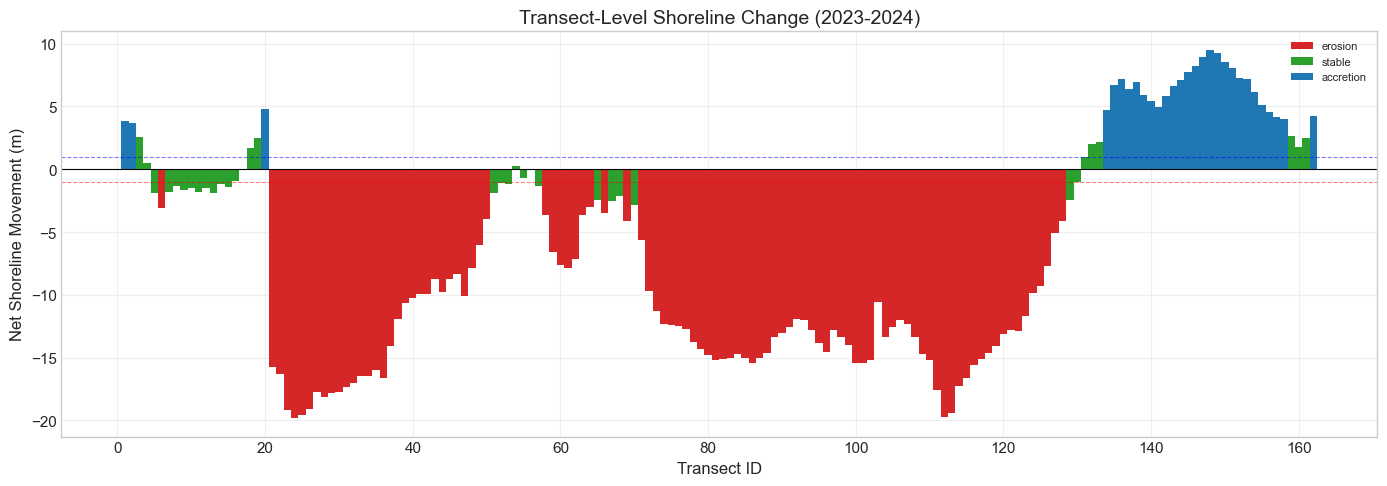

In [6]:
# =============================================================================
# Section 1.2 — Spatial profile plot (latest shoreline interval)
# =============================================================================

color_map = {
    'erosion':   '#d62728',
    'stable':    '#2ca02c',
    'accretion': '#1f77b4',
}

plot_df = latest_dsas_df.copy().sort_values('id')

fig, ax = plt.subplots(figsize=(14, 5))
for cls, clr in color_map.items():
    mask = plot_df['epr_class'] == cls
    ax.bar(
        plot_df.loc[mask, 'id'],
        plot_df.loc[mask, 'NSM'],
        color=clr,
        label=cls,
        width=1.0,
        edgecolor='none'
    )

ax.axhline(0, color='black', lw=0.8)
ax.axhline(EROSION_THRESHOLD, color='red', ls='--', lw=0.8, alpha=0.5)
ax.axhline(ACCRETION_THRESHOLD, color='blue', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Transect ID')
ax.set_ylabel('Net Shoreline Movement (m)')
ax.set_title(f'Transect-Level Shoreline Change ({latest_interval_label})')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

print(f"Latest interval plotted: {latest_interval_label}")
plt.tight_layout()
plt.savefig('./figures/transect_profile.png', dpi=150)
plt.show()


## Section 2 — Environmental Forcing Data → Monthly Time Series

Convert the three oceanographic NetCDF datasets into a **uniform monthly table** that the pattern analysis in Section 3 can consume directly.

Each monsoon year (April–March) of monthly data is paired with the corresponding shoreline interval label when building pattern features.

| Dataset | NetCDF Source | Variables | Monthly stats |
|---------|---------------|-----------|---------------|
| **Wave** | Global Ocean Waves Reanalysis | VHM0, VTPK, VMDR, VSDX, VSDY | max, mean |
| **Wind** | Sea Surface Wind & Stress | wind_speed, eastward_wind, northward_wind | max, mean |
| **Current** | Global Ocean Physics Reanalysis | uo, vo, zos | max, mean |

**Output:** `monthly_combined` — one row per calendar month, all three forcing sources merged. This feeds directly into Section 3.


In [7]:
# =============================================================================
# Section 2.1 — Convert Wind NetCDF to Monthly Dataset (Per-Variable)
# =============================================================================

WIND_VARS = ['wind_speed', 'eastward_wind', 'northward_wind']

wind_df = wind_ds[WIND_VARS].to_dataframe().reset_index()
wind_df = wind_df.dropna(subset=['wind_speed'])

def assign_monsoon_year(time):
    """April (Year N) – March (Year N+1) → Monsoon Year N"""
    ts = pd.Timestamp(time)
    return ts.year if ts.month >= 4 else ts.year - 1

wind_df['monsoon_year'] = wind_df['time'].apply(assign_monsoon_year)
wind_df['year_month'] = wind_df['time'].dt.to_period('M')

# ── Monthly Wind Dataset (per-variable max & mean) ──
wind_monthly = wind_df.groupby(['monsoon_year', 'year_month']).agg({
    'wind_speed': ['max', 'mean'],
    'eastward_wind': ['max', 'mean'],
    'northward_wind': ['max', 'mean'],
    'time': 'first',
}).reset_index()
wind_monthly.columns = ['monsoon_year', 'year_month',
                        'wind_speed_max', 'wind_speed_mean',
                        'eastward_wind_max', 'eastward_wind_mean',
                        'northward_wind_max', 'northward_wind_mean',
                        'time']

print("=" * 60)
print("MONTHLY WIND DATASET (Per-Variable)")
print("=" * 60)
print(f"Shape: {wind_monthly.shape}")
print(f"Period: {wind_monthly['year_month'].min()} – {wind_monthly['year_month'].max()}")
print(f"Variables: wind_speed, eastward_wind, northward_wind")
print(f"Features: {[c for c in wind_monthly.columns if c not in ['time', 'monsoon_year', 'year_month']]}")
display(wind_monthly.head(12))

# ── Annual aggregation (per-variable) ──
wind_annual = wind_df.groupby('monsoon_year').agg({
    'wind_speed': ['max', 'mean'],
    'eastward_wind': ['max', 'mean'],
    'northward_wind': ['max', 'mean'],
}).reset_index()
wind_annual.columns = ['monsoon_year',
                       'wind_speed_max_annual', 'wind_speed_mean_annual',
                       'eastward_wind_max_annual', 'eastward_wind_mean_annual',
                       'northward_wind_max_annual', 'northward_wind_mean_annual']

print(f"\nWind monthly: {wind_monthly.shape}  |  Wind annual: {wind_annual.shape}")

MONTHLY WIND DATASET (Per-Variable)
Shape: (156, 9)
Period: 2012-01 – 2024-12
Variables: wind_speed, eastward_wind, northward_wind
Features: ['wind_speed_max', 'wind_speed_mean', 'eastward_wind_max', 'eastward_wind_mean', 'northward_wind_max', 'northward_wind_mean']


,monsoon_year,year_month,wind_speed_max,wind_speed_mean,eastward_wind_max,eastward_wind_mean,northward_wind_max,northward_wind_mean,time
0,2011,2012-01,3.07,3.07,0.28,0.28,-1.30,-1.30,2012-01-01
1,2011,2012-02,2.59,2.59,0.13,0.13,-0.02,-0.02,2012-02-01
2,2011,2012-03,2.94,2.94,0.99,0.99,0.92,0.92,2012-03-01
3,2012,2012-04,3.18,3.18,1.44,1.44,1.83,1.83,2012-04-01
4,2012,2012-05,5.57,5.57,4.91,4.91,2.35,2.35,2012-05-01
5,2012,2012-06,5.96,5.96,5.29,5.29,2.19,2.19,2012-06-01
6,2012,2012-07,6.00,6.00,5.65,5.65,1.06,1.06,2012-07-01
7,2012,2012-08,5.18,5.18,4.33,4.33,2.05,2.05,2012-08-01
8,2012,2012-09,4.84,4.84,3.84,3.84,2.22,2.22,2012-09-01
9,2012,2012-10,3.81,3.81,1.36,1.36,1.39,1.39,2012-10-01



Wind monthly: (156, 9)  |  Wind annual: (14, 7)


In [8]:
# =============================================================================
# Section 2.2 — Convert Wave NetCDF to Monthly Dataset (Per-Variable)
# =============================================================================

WAVE_VARS = ['VHM0', 'VTPK', 'VMDR', 'VSDX', 'VSDY']

# Select single nearest longitude point (wave file may have multiple)
wave_sel = wave_ds
if 'longitude' in wave_ds.dims and wave_ds.sizes['longitude'] > 1:
    wave_sel = wave_ds.isel(longitude=0)
    print(f"Selected wave longitude: {float(wave_sel.longitude.values)}")
if 'latitude' in wave_ds.dims and wave_ds.sizes['latitude'] > 1:
    wave_sel = wave_sel.isel(latitude=0)
    print(f"Selected wave latitude: {float(wave_sel.latitude.values)}")

# Auto-detect available variables
available_wave_vars = [v for v in WAVE_VARS if v in wave_sel.data_vars]
missing_wave_vars = [v for v in WAVE_VARS if v not in wave_sel.data_vars]
if missing_wave_vars:
    print(f"⚠ Missing wave variables (will be filled with 0): {missing_wave_vars}")

wave_df = wave_sel[available_wave_vars].to_dataframe().reset_index()
wave_df = wave_df.dropna(subset=['VHM0'])

# Fill missing variables with 0
for mv in missing_wave_vars:
    wave_df[mv] = 0.0

wave_df['monsoon_year'] = wave_df['time'].apply(assign_monsoon_year)
wave_df['year_month'] = wave_df['time'].dt.to_period('M')

print(f"Wave records: {len(wave_df)}")
print(f"Time range: {wave_df['time'].min()} – {wave_df['time'].max()}")
print(f"Available: {available_wave_vars} | Missing: {missing_wave_vars}")

# ── Monthly Wave Dataset (per-variable max & mean) ──
wave_monthly = wave_df.groupby(['monsoon_year', 'year_month']).agg({
    'VHM0': ['max', 'mean'],
    'VTPK': ['max', 'mean'],
    'VMDR': ['mean'],
    'VSDX': ['max', 'mean'],
    'VSDY': ['max', 'mean'],
    'time': 'first',
}).reset_index()
wave_monthly.columns = ['monsoon_year', 'year_month',
                        'VHM0_max', 'VHM0_mean',
                        'VTPK_max', 'VTPK_mean',
                        'VMDR_mean',
                        'VSDX_max', 'VSDX_mean',
                        'VSDY_max', 'VSDY_mean',
                        'time']

print("=" * 60)
print("MONTHLY WAVE DATASET (Per-Variable)")
print("=" * 60)
print(f"Shape: {wave_monthly.shape}")
print(f"Period: {wave_monthly['year_month'].min()} – {wave_monthly['year_month'].max()}")
print(f"Variables: VHM0, VTPK, VMDR, VSDX, VSDY")
print(f"Features: {[c for c in wave_monthly.columns if c not in ['time', 'monsoon_year', 'year_month']]}")
display(wave_monthly.head(12))

# ── Annual aggregation (per-variable) ──
wave_annual = wave_df.groupby('monsoon_year').agg({
    'VHM0': ['max', 'mean'],
    'VTPK': ['max', 'mean'],
    'VMDR': ['mean'],
    'VSDX': ['max', 'mean'],
    'VSDY': ['max', 'mean'],
}).reset_index()
wave_annual.columns = ['monsoon_year',
                       'VHM0_max_annual', 'VHM0_mean_annual',
                       'VTPK_max_annual', 'VTPK_mean_annual',
                       'VMDR_mean_annual',
                       'VSDX_max_annual', 'VSDX_mean_annual',
                       'VSDY_max_annual', 'VSDY_mean_annual']

print(f"\nWave monthly: {wave_monthly.shape}  |  Wave annual: {wave_annual.shape}")

Wave records: 35033
Time range: 2013-01-01 21:00:00 – 2024-12-28 21:00:00
Available: ['VHM0', 'VTPK', 'VMDR', 'VSDX', 'VSDY'] | Missing: []
MONTHLY WAVE DATASET (Per-Variable)
Shape: (144, 12)
Period: 2013-01 – 2024-12
Variables: VHM0, VTPK, VMDR, VSDX, VSDY
Features: ['VHM0_max', 'VHM0_mean', 'VTPK_max', 'VTPK_mean', 'VMDR_mean', 'VSDX_max', 'VSDX_mean', 'VSDY_max', 'VSDY_mean']


,monsoon_year,year_month,VHM0_max,VHM0_mean,VTPK_max,VTPK_mean,VMDR_mean,VSDX_max,VSDX_mean,VSDY_max,VSDY_mean,time
0,2012,2013-01,1.05,0.675934,19.740000,12.890249,225.045563,0.05,0.008631,0.00,-0.012656,2013-01-01 21:00:00
1,2012,2013-02,1.15,0.733304,19.730000,13.817009,205.662491,0.02,0.004821,0.01,-0.004152,2013-02-01 00:00:00
2,2012,2013-03,1.02,0.666411,19.650000,12.814073,189.654190,0.02,0.002016,0.01,-0.000685,2013-03-01 00:00:00
3,2013,2013-04,1.44,0.879250,22.080000,13.826583,205.640198,0.05,0.015208,0.01,0.003333,2013-04-01 00:00:00
4,2013,2013-05,2.42,1.643185,19.719999,9.901452,228.725647,0.09,0.053952,0.05,0.023306,2013-05-01 00:00:00
5,2013,2013-06,3.05,1.949833,20.150000,11.890834,249.528366,0.13,0.070292,0.05,0.013792,2013-06-01 00:00:00
6,2013,2013-07,2.30,1.767097,17.870001,10.886693,250.226135,0.11,0.061411,0.03,0.011976,2013-07-01 00:00:00
7,2013,2013-08,2.79,1.649839,21.129999,11.793992,237.460892,0.13,0.057903,0.02,0.011250,2013-08-01 00:00:00
8,2013,2013-09,2.22,1.571000,19.969999,12.174042,228.883286,0.09,0.053167,0.05,0.018208,2013-09-01 00:00:00
9,2013,2013-10,1.89,1.309355,20.469999,11.774153,219.998947,0.09,0.041210,0.04,0.014798,2013-10-01 00:00:00



Wave monthly: (144, 12)  |  Wave annual: (13, 10)


In [9]:
# =============================================================================
# Section 2.3 — Convert Current NetCDF to Monthly Dataset (Per-Variable)
# =============================================================================

CURRENT_VARS = ['uo', 'vo', 'zos']

# Select surface depth (index 0) for uo, vo
if 'depth' in current_ds.dims:
    current_surface = current_ds.isel(depth=0)
else:
    current_surface = current_ds

current_df = current_surface[CURRENT_VARS].to_dataframe().reset_index()
current_df = current_df.dropna(subset=['uo'])
current_df['monsoon_year'] = current_df['time'].apply(assign_monsoon_year)
current_df['year_month'] = current_df['time'].dt.to_period('M')

# ── Monthly Current Dataset (per-variable max & mean) ──
current_monthly = current_df.groupby(['monsoon_year', 'year_month']).agg({
    'uo': ['max', 'mean'],
    'vo': ['max', 'mean'],
    'zos': ['max', 'mean'],
    'time': 'first',
}).reset_index()
current_monthly.columns = ['monsoon_year', 'year_month',
                           'uo_max', 'uo_mean',
                           'vo_max', 'vo_mean',
                           'zos_max', 'zos_mean', 'time']

print("=" * 60)
print("MONTHLY CURRENT DATASET (Per-Variable)")
print("=" * 60)
print(f"Shape: {current_monthly.shape}")
print(f"Period: {current_monthly['year_month'].min()} – {current_monthly['year_month'].max()}")
print(f"Variables: uo, vo, zos")
print(f"Features: {[c for c in current_monthly.columns if c not in ['time', 'monsoon_year', 'year_month']]}")
display(current_monthly.head(12))

# ── Annual aggregation (per-variable) ──
current_annual = current_df.groupby('monsoon_year').agg({
    'uo': ['max', 'mean'],
    'vo': ['max', 'mean'],
    'zos': ['max', 'mean'],
}).reset_index()
current_annual.columns = ['monsoon_year',
                          'uo_max_annual', 'uo_mean_annual',
                          'vo_max_annual', 'vo_mean_annual',
                          'zos_max_annual', 'zos_mean_annual']

print(f"\nCurrent monthly: {current_monthly.shape}  |  Current annual: {current_annual.shape}")

MONTHLY CURRENT DATASET (Per-Variable)
Shape: (146, 9)
Period: 2012-02 – 2024-03
Variables: uo, vo, zos
Features: ['uo_max', 'uo_mean', 'vo_max', 'vo_mean', 'zos_max', 'zos_mean']


,monsoon_year,year_month,uo_max,uo_mean,vo_max,vo_mean,zos_max,zos_mean,time
0,2011,2012-02,-0.106204,-0.106204,-0.028687,-0.028687,0.520341,0.520341,2012-02-01
1,2011,2012-03,0.007935,0.007935,-0.004883,-0.004883,0.468154,0.468154,2012-03-01
2,2012,2012-04,0.032350,0.032350,-0.019532,-0.019532,0.531938,0.531938,2012-04-01
3,2012,2012-05,0.090335,0.090335,-0.100101,-0.100101,0.443129,0.443129,2012-05-01
4,2012,2012-06,0.065920,0.065920,-0.052492,-0.052492,0.426649,0.426649,2012-06-01
5,2012,2012-07,0.042116,0.042116,-0.076296,-0.076296,0.420240,0.420240,2012-07-01
6,2012,2012-08,0.054323,0.054323,0.013428,0.013428,0.391247,0.391247,2012-08-01
7,2012,2012-09,0.029908,0.029908,0.016480,0.016480,0.419935,0.419935,2012-09-01
8,2012,2012-10,-0.023804,-0.023804,0.042726,0.042726,0.436415,0.436415,2012-10-01
9,2012,2012-11,-0.028687,-0.028687,-0.047609,-0.047609,0.503861,0.503861,2012-11-01



Current monthly: (146, 9)  |  Current annual: (13, 7)


### Section 2.4 — Merge into Unified Monthly Forcing Table (`monthly_combined`)

Wave, Wind, and Current monthly datasets are joined on `monsoon_year` and `year_month` into a single table.

Each row = one calendar month. `year_month` is the primary time index.

> **`monthly_combined` is the key input for the pattern feature extraction in Section 3.**


In [10]:
# =============================================================================
# Section 2.4 — Display monthly datasets
# =============================================================================

# Merge into one combined monthly dataset
monthly_combined = wave_monthly.merge(
    wind_monthly, on=['monsoon_year', 'year_month'], how='outer', suffixes=('_wave', '_wind')
)
monthly_combined = monthly_combined.merge(
    current_monthly, on=['monsoon_year', 'year_month'], how='outer'
)
monthly_combined = monthly_combined.sort_values('year_month').reset_index(drop=True)

print("=" * 60)
print("MONTHLY DATASET SUMMARY")
print("=" * 60)
print(f"  Wave monthly  : {wave_monthly.shape[0]} months × {wave_monthly.shape[1] - 2} features")
print(f"  Wind monthly  : {wind_monthly.shape[0]} months × {wind_monthly.shape[1] - 2} features")
print(f"  Current monthly: {current_monthly.shape[0]} months × {current_monthly.shape[1] - 2} features")
print(f"  Combined monthly: {monthly_combined.shape}")

print(f"\n{'='*60}")
print("COMBINED MONTHLY FORCING (first 12 months)")
print("=" * 60)
display(monthly_combined.head(12))

MONTHLY DATASET SUMMARY
  Wave monthly  : 144 months × 10 features
  Wind monthly  : 156 months × 7 features
  Current monthly: 146 months × 7 features
  Combined monthly: (156, 26)

COMBINED MONTHLY FORCING (first 12 months)


,monsoon_year,year_month,VHM0_max,VHM0_mean,VTPK_max,VTPK_mean,VMDR_mean,VSDX_max,VSDX_mean,VSDY_max,...,northward_wind_max,northward_wind_mean,time_wind,uo_max,uo_mean,vo_max,vo_mean,zos_max,zos_mean,time
0,2011,2012-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.30,-1.30,2012-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaT
1,2011,2012-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.02,-0.02,2012-02-01,-0.106204,-0.106204,-0.028687,-0.028687,0.520341,0.520341,2012-02-01
2,2011,2012-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.92,0.92,2012-03-01,0.007935,0.007935,-0.004883,-0.004883,0.468154,0.468154,2012-03-01
3,2012,2012-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.83,1.83,2012-04-01,0.032350,0.032350,-0.019532,-0.019532,0.531938,0.531938,2012-04-01
4,2012,2012-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.35,2.35,2012-05-01,0.090335,0.090335,-0.100101,-0.100101,0.443129,0.443129,2012-05-01
5,2012,2012-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.19,2.19,2012-06-01,0.065920,0.065920,-0.052492,-0.052492,0.426649,0.426649,2012-06-01
6,2012,2012-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.06,1.06,2012-07-01,0.042116,0.042116,-0.076296,-0.076296,0.420240,0.420240,2012-07-01
7,2012,2012-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.05,2.05,2012-08-01,0.054323,0.054323,0.013428,0.013428,0.391247,0.391247,2012-08-01
8,2012,2012-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.22,2.22,2012-09-01,0.029908,0.029908,0.016480,0.016480,0.419935,0.419935,2012-09-01
9,2012,2012-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.39,1.39,2012-10-01,-0.023804,-0.023804,0.042726,0.042726,0.436415,0.436415,2012-10-01


## Section 3 — Three-Class Monthly Threshold Workflow

**This is the core research analysis.** Using the three-class shoreline labels and monthly pattern signatures extracted from the wave, wind, and current forcing data.

Steps:

1. Uses the shoreline CSV **file name year** as the authoritative shoreline interval key.
2. Keeps the shoreline target in the **three-class** form: `erosion`, `stable`, `accretion`.
3. Learns **monthly pattern signatures** (anomaly-based features: percentiles, slopes, anomaly runs) inside each monsoon-year interval (full April–March window).
4. Estimates **two boundary thresholds per driver**: `erosion_onset`, `accretion_onset` — forming the threshold range for each coastal driver.
5. Forecasts **future threshold ranges directly from historical threshold trajectories** using TheilSen regression — 24 months ahead at H6, H12, H18, H24 horizons.

**If a shoreline class is absent in the historical record**, the notebook keeps that class in the ordered framework but reports its threshold as structurally unsupported rather than inventing values.


In [11]:
# =============================================================================
# Section 3.1 — Year-Wise Label Check + Core Driver Pattern Feature Extraction
# =============================================================================
# The analysis is intentionally restricted to the requested core erosion drivers:
#   Wave    : VHM0_mean, VTPK_mean, VMDR_mean
#   Wind    : eastward_wind_mean, northward_wind_mean
#   Current : uo_mean, vo_mean, zos_mean
# This guarantees threshold estimation covers wave, wind, and current together.
#
# For each monsoon year (April–March), anomaly-based pattern features are extracted
# from these core drivers only.
#
# Features computed per driver per interval (14 per driver):
#   __p10, __p50, __p90, __iqr
#   __anom_mean, __anom_peak_pos, __anom_peak_neg, __anom_abs_sum
#   __anom_pos_months, __anom_neg_months, __run_pos, __run_neg
#   __late_minus_early, __slope
#
# Outputs:
#   pattern_df                — one row per monsoon year (for pattern recognition)
#   monthly_driver_labeled_df — monthly rows tagged with final year label
#   year_driver_ranges_df     — per-year driver value ranges (q25-q75, min-max)
# =============================================================================

# Ordered class labels and code mappings (codes 0-2 map erosion -> stable -> accretion)
THREE_CLASS_ORDER = ['erosion', 'stable', 'accretion']
CLASS_TO_CODE = {label: idx for idx, label in enumerate(THREE_CLASS_ORDER)}
CODE_TO_CLASS = {idx: label for label, idx in CLASS_TO_CODE.items()}

# User-requested environmental drivers used throughout pattern recognition and thresholds
CORE_DRIVER_FEATURES = [
    'VHM0_mean',
    'VTPK_mean',
    'VMDR_mean',
    'eastward_wind_mean',
    'northward_wind_mean',
    'uo_mean',
    'vo_mean',
    'zos_mean',
]

MIN_INTERVAL_MONTHS = 8   # skip any interval with fewer months of forcing data
SEASON_SPLIT_MONTHS = 6   # split window for late_minus_early feature


def longest_run(mask):
    """Count the longest consecutive True run in a boolean array."""
    best = 0
    current = 0
    for flag in mask:
        if bool(flag):
            current += 1
            best = max(best, current)
        else:
            current = 0
    return int(best)


# -- STEP 1: Year-wise shoreline label review (must be checked before modelling) --
shoreline_annual = shoreline_annual.copy()
shoreline_annual['Change_Class'] = pd.Categorical(
    shoreline_annual['Change_Class'],
    categories=THREE_CLASS_ORDER,
    ordered=True,
)
shoreline_annual['class_code'] = shoreline_annual['Change_Class'].map(CLASS_TO_CODE).astype(int)
shoreline_annual['shoreline_score'] = shoreline_annual['class_code'] - 1   # centred: -1 to +1

yearwise_label_df = (
    shoreline_annual[['year', 'interval_label', 'Change_Class', 'annual_NSM', 'NSM_count']]
    .rename(columns={'year': 'monsoon_year'})
    .sort_values('monsoon_year')
    .reset_index(drop=True)
)

print('=== YEAR-WISE SHORELINE LABEL CHECK (BEFORE PATTERN ANALYSIS) ===')
print(yearwise_label_df.to_string(index=False))


# -- STEP 2: Restrict monthly forcing table to core drivers only --
monthly_combined = monthly_combined.copy()
year_month_series = monthly_combined['year_month']
if pd.api.types.is_period_dtype(year_month_series):
    year_month_series = year_month_series.dt.to_timestamp(how='start')
else:
    year_month_series = pd.to_datetime(year_month_series).dt.to_period('M').dt.to_timestamp()
monthly_combined['year_month'] = year_month_series
monthly_combined = monthly_combined.sort_values('year_month').reset_index(drop=True)

missing_core_drivers = [driver for driver in CORE_DRIVER_FEATURES if driver not in monthly_combined.columns]
if missing_core_drivers:
    raise ValueError(
        f"Missing required core driver columns: {missing_core_drivers}. "
        f"Available columns: {list(monthly_combined.columns)}"
    )

monthly_feature_cols = CORE_DRIVER_FEATURES.copy()


# -- STEP 3: Monthly climatology for anomaly features (core drivers only) --
monthly_climatology = {}
for feature_name in monthly_feature_cols:
    climatology = monthly_combined[['year_month', feature_name]].copy()
    climatology['calendar_month'] = climatology['year_month'].dt.month
    monthly_climatology[feature_name] = (
        climatology.groupby('calendar_month')[feature_name]
        .agg(
            mean='mean',
            std='std',
            q10=lambda series: series.quantile(0.10),
            q90=lambda series: series.quantile(0.90),
        )
        .replace({'std': {0.0: np.nan}})
    )


# -- STEP 4: Interval-level pattern feature extraction + monthly driver table --
interval_feature_rows = []
interval_month_lookup = {}
monthly_driver_rows = []

for shoreline_row in shoreline_annual.sort_values('year').itertuples(index=False):
    monsoon_year = int(shoreline_row.year)

    # Year key = END year, so forcing window is previous April to current March
    # Example: year_key=2013 -> forcing window April 2012 to March 2013
    window_start = pd.Timestamp(f'{monsoon_year - 1}-04-01')
    window_end = pd.Timestamp(f'{monsoon_year}-03-01')

    interval_window = monthly_combined[
        monthly_combined['year_month'].between(window_start, window_end)
    ].copy()

    if len(interval_window) < MIN_INTERVAL_MONTHS:
        print(
            f"[SKIPPED] {shoreline_row.interval_label}: only {len(interval_window)} monthly records available"
        )
        continue

    interval_window = interval_window.sort_values('year_month').reset_index(drop=True)
    interval_month_lookup[monsoon_year] = interval_window.copy()

    # Save monthly rows with final interval label (used for direct driver thresholds)
    labeled_months = interval_window[['year_month'] + monthly_feature_cols].copy()
    labeled_months.insert(0, 'monsoon_year', monsoon_year)
    labeled_months.insert(1, 'interval_label', shoreline_row.interval_label)
    labeled_months['Change_Class'] = shoreline_row.Change_Class
    labeled_months['class_code'] = int(shoreline_row.class_code)
    monthly_driver_rows.append(labeled_months)

    # Base row: metadata + class label
    feature_row = {
        'monsoon_year': monsoon_year,
        'interval_label': shoreline_row.interval_label,
        'n_months': int(len(interval_window)),
        'Change_Class': shoreline_row.Change_Class,
        'class_code': int(shoreline_row.class_code),
        'shoreline_score': int(shoreline_row.shoreline_score),
        'annual_NSM': float(shoreline_row.annual_NSM),
        'NSM_count': int(shoreline_row.NSM_count),
    }

    # Compute 14 anomaly-based pattern features per core driver
    for feature_name in monthly_feature_cols:
        values = interval_window[feature_name].astype(float).to_numpy()
        if np.all(np.isnan(values)):
            continue

        calendar_months = interval_window['year_month'].dt.month.to_numpy()
        climatology = monthly_climatology[feature_name].reindex(calendar_months)
        climatology_mean = climatology['mean'].to_numpy(dtype=float)
        climatology_std = climatology['std'].to_numpy(dtype=float)

        anomalies = np.divide(
            values - climatology_mean,
            climatology_std,
            out=np.zeros_like(values, dtype=float),
            where=np.isfinite(climatology_std) & (climatology_std > 0),
        )
        anomalies = np.where(np.isfinite(anomalies), anomalies, 0.0)

        half_window = min(SEASON_SPLIT_MONTHS, max(len(values) // 2, 1))
        early_values = values[:half_window]
        late_values = values[-half_window:]
        time_index = np.arange(len(values), dtype=float)

        slope = 0.0
        if len(values) >= 2 and np.nanstd(values) > 0:
            slope = float(np.polyfit(time_index, values, 1)[0])

        feature_row[f'{feature_name}__p10'] = float(np.nanpercentile(values, 10))
        feature_row[f'{feature_name}__p50'] = float(np.nanpercentile(values, 50))
        feature_row[f'{feature_name}__p90'] = float(np.nanpercentile(values, 90))
        feature_row[f'{feature_name}__iqr'] = float(np.nanpercentile(values, 75) - np.nanpercentile(values, 25))
        feature_row[f'{feature_name}__anom_mean'] = float(np.nanmean(anomalies))
        feature_row[f'{feature_name}__anom_peak_pos'] = float(np.nanmax(anomalies))
        feature_row[f'{feature_name}__anom_peak_neg'] = float(np.nanmin(anomalies))
        feature_row[f'{feature_name}__anom_abs_sum'] = float(np.nansum(np.abs(anomalies)))
        feature_row[f'{feature_name}__anom_pos_months'] = int(np.sum(anomalies >= 1.0))
        feature_row[f'{feature_name}__anom_neg_months'] = int(np.sum(anomalies <= -1.0))
        feature_row[f'{feature_name}__run_pos'] = longest_run(anomalies >= 1.0)
        feature_row[f'{feature_name}__run_neg'] = longest_run(anomalies <= -1.0)
        feature_row[f'{feature_name}__late_minus_early'] = float(np.nanmean(late_values) - np.nanmean(early_values))
        feature_row[f'{feature_name}__slope'] = slope

    interval_feature_rows.append(feature_row)


# pattern_df: one row per monsoon year (downstream pattern-recognition input)
analysis_df = pd.DataFrame(interval_feature_rows).sort_values('monsoon_year').reset_index(drop=True)
pattern_df = analysis_df.copy()

# monthly rows tagged with final year label (for direct driver threshold estimation)
monthly_driver_labeled_df = (
    pd.concat(monthly_driver_rows, ignore_index=True)
    if monthly_driver_rows
    else pd.DataFrame(
        columns=['monsoon_year', 'interval_label', 'year_month', 'Change_Class', 'class_code'] + monthly_feature_cols
    )
)

# Per-year dominant driver ranges (example style: 0.50 to 0.70)
if len(monthly_driver_labeled_df) > 0:
    _driver_long = (
        monthly_driver_labeled_df
        .melt(
            id_vars=['monsoon_year', 'interval_label', 'year_month', 'Change_Class', 'class_code'],
            value_vars=monthly_feature_cols,
            var_name='driver',
            value_name='value',
        )
        .dropna(subset=['value'])
    )

    year_driver_ranges_df = (
        _driver_long.groupby(['monsoon_year', 'Change_Class', 'driver'])['value']
        .agg(
            min_value='min',
            q25=lambda s: float(s.quantile(0.25)),
            median_value='median',
            q75=lambda s: float(s.quantile(0.75)),
            max_value='max',
            n_months='count',
        )
        .reset_index()
        .sort_values(['monsoon_year', 'driver'])
        .reset_index(drop=True)
    )
    year_driver_ranges_df['dominant_range'] = (
        year_driver_ranges_df['q25'].map(lambda v: f"{v:.3f}")
        + ' to '
        + year_driver_ranges_df['q75'].map(lambda v: f"{v:.3f}")
    )
    year_driver_ranges_df['full_range'] = (
        year_driver_ranges_df['min_value'].map(lambda v: f"{v:.3f}")
        + ' to '
        + year_driver_ranges_df['max_value'].map(lambda v: f"{v:.3f}")
    )
else:
    year_driver_ranges_df = pd.DataFrame(
        columns=['monsoon_year', 'Change_Class', 'driver', 'min_value', 'q25', 'median_value', 'q75', 'max_value', 'n_months', 'dominant_range', 'full_range']
    )


print('\n=== CORE DRIVERS USED (FIXED AS REQUESTED) ===')
print(monthly_feature_cols)

print('\n=== FIVE-CLASS MONTHLY PATTERN DATASET ===')
print(f'Intervals retained : {len(pattern_df)} / {len(shoreline_annual)}')
print(f'Core drivers       : {len(monthly_feature_cols)}')
print(f'Pattern feature cols: {pattern_df.shape[1] - 8}')
print('\nClass counts:')
print(pattern_df['Change_Class'].value_counts().reindex(THREE_CLASS_ORDER, fill_value=0).to_string())
print('\nInterval coverage:')
print(pattern_df[['monsoon_year', 'interval_label', 'n_months', 'Change_Class', 'annual_NSM']].to_string(index=False))

print('\n=== YEAR-WISE DRIVER VALUE RANGES (MONTHLY WITHIN EACH INTERVAL) ===')
if len(year_driver_ranges_df) == 0:
    print('No year-wise driver ranges available.')
else:
    print(
        year_driver_ranges_df[
            ['monsoon_year', 'Change_Class', 'driver', 'dominant_range', 'full_range', 'median_value']
        ].to_string(index=False)
    )


=== YEAR-WISE SHORELINE LABEL CHECK (BEFORE PATTERN ANALYSIS) ===
 monsoon_year interval_label Change_Class  annual_NSM  NSM_count
         2013      2012-2013      erosion   -2.677923        162
         2014      2013-2014      erosion   -6.502348        164
         2015      2014-2015    accretion    4.247188        158
         2016      2015-2016      erosion   -3.300930        159
         2017      2016-2017    accretion    3.720458        163
         2018      2017-2018    accretion    1.870692        162
         2019      2018-2019      erosion   -4.807674        161
         2020      2019-2020      erosion   -3.760938        160
         2021      2020-2021    accretion    1.629167        164
         2022      2021-2022    accretion    1.731679        163
         2023      2022-2023       stable    0.606899        161
         2024      2023-2024      erosion   -6.900769        162

=== CORE DRIVERS USED (FIXED AS REQUESTED) ===
['VHM0_mean', 'VTPK_mean', 'VMDR_mean', '

In [12]:
# =============================================================================
# Section 3.2 — Feature-Importance-First Three-Class Pattern Recognition
#               LOOCV Ensemble + SHAP (Core Drivers Preserved)
# =============================================================================
# TECHNIQUE OVERVIEW
# ------------------
# 1. Screen pattern features using a composite score:
#      Spearman(|rho|) + Mutual Information + Kruskal-Wallis separation.
# 2. Enforce coverage of all required core drivers first (wave, wind, current).
# 3. Train an ensemble under Leave-One-Out Cross-Validation (LOOCV):
#      Multinomial Logit + Gradient Boosting + Random Forest.
# 4. Explain feature and driver importance with SHAP and permutation importance.
# =============================================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize
import shap

PATTERN_META_COLS = [
    'monsoon_year', 'interval_label', 'n_months',
    'Change_Class', 'class_code', 'shoreline_score',
    'annual_NSM', 'NSM_count',
]
MAX_FEATURES_PER_DRIVER = 2
MAX_SELECTED_FEATURES = 14

pattern_feature_cols = [col for col in pattern_df.columns if col not in PATTERN_META_COLS]
if len(pattern_feature_cols) == 0:
    raise ValueError('No pattern features found. Check Section 3.1 feature extraction output.')

present_class_codes = sorted(pattern_df['class_code'].unique())
present_class_labels = [CODE_TO_CLASS[code] for code in present_class_codes]

# -- Step 1: Feature screening (Spearman + Kruskal-Wallis + MI composite) --
feature_screening_rows = []

mi_input = pattern_df[pattern_feature_cols].copy()
mi_input = mi_input.replace([np.inf, -np.inf], np.nan).fillna(mi_input.median(numeric_only=True))
mi_scores = mutual_info_classif(
    mi_input,
    pattern_df['class_code'],
    random_state=42,
    discrete_features=False,
)
mi_lookup = dict(zip(pattern_feature_cols, mi_scores))

for feature_name in pattern_feature_cols:
    feature_values = pattern_df[feature_name].astype(float)
    valid_mask = feature_values.notna()
    if valid_mask.sum() < 6 or feature_values.nunique(dropna=True) < 3:
        continue

    rho, rho_p = spearmanr(
        feature_values[valid_mask],
        pattern_df.loc[valid_mask, 'shoreline_score'],
        nan_policy='omit',
    )
    if not np.isfinite(rho):
        rho, rho_p = 0.0, 1.0

    class_groups = [
        pattern_df.loc[pattern_df['Change_Class'] == cls, feature_name].dropna().values
        for cls in present_class_labels
        if pattern_df.loc[pattern_df['Change_Class'] == cls, feature_name].dropna().size > 0
    ]
    kw_stat, kw_p = kruskal(*class_groups) if len(class_groups) >= 2 else (np.nan, 1.0)

    composite_score = (
        2.0 * abs(float(rho))
        + float(mi_lookup.get(feature_name, 0.0))
        + max(0.0, -np.log10(float(kw_p) + 1e-12))
    )

    feature_screening_rows.append({
        'feature': feature_name,
        'driver': feature_name.split('__')[0],
        'spearman_rho': float(rho),
        'spearman_p': float(rho_p) if np.isfinite(rho_p) else 1.0,
        'kruskal_h': float(kw_stat) if np.isfinite(kw_stat) else np.nan,
        'kruskal_p': float(kw_p) if np.isfinite(kw_p) else 1.0,
        'mutual_info': float(mi_lookup.get(feature_name, 0.0)),
        'composite_score': float(composite_score),
    })

screening_df = (
    pd.DataFrame(feature_screening_rows)
    .sort_values(['composite_score', 'mutual_info', 'kruskal_h'], ascending=[False, False, False])
    .reset_index(drop=True)
)
if len(screening_df) == 0:
    raise ValueError('Feature screening produced no usable features. Check data coverage in Section 3.1.')

# -- Step 2: Driver-constrained feature selection --
# First pass: keep at least 1 feature from each requested driver.
selected_features = []
driver_feature_counts = {driver: 0 for driver in CORE_DRIVER_FEATURES}

for driver in CORE_DRIVER_FEATURES:
    drows = screening_df[screening_df['driver'] == driver]
    if len(drows) == 0:
        continue
    top_driver_feature = drows.iloc[0]['feature']
    selected_features.append(top_driver_feature)
    driver_feature_counts[driver] += 1

# Second pass: add additional high-score features while respecting per-driver cap.
for screening_row in screening_df.itertuples(index=False):
    feature_name = screening_row.feature
    driver_name = screening_row.driver

    if feature_name in selected_features:
        continue
    if driver_name not in driver_feature_counts:
        continue
    if driver_feature_counts[driver_name] >= MAX_FEATURES_PER_DRIVER:
        continue

    selected_features.append(feature_name)
    driver_feature_counts[driver_name] += 1

    if len(selected_features) >= min(MAX_SELECTED_FEATURES, len(screening_df)):
        break

missing_driver_coverage = [d for d in CORE_DRIVER_FEATURES if driver_feature_counts.get(d, 0) == 0]
if missing_driver_coverage:
    print(f"WARNING: no screenable features available for drivers: {missing_driver_coverage}")

if len(selected_features) == 0:
    raise ValueError('No selected features available for model training.')

feature_matrix = pattern_df[selected_features].replace([np.inf, -np.inf], np.nan)
feature_matrix = feature_matrix.fillna(feature_matrix.median(numeric_only=True))
X_pattern = feature_matrix.to_numpy(dtype=float)
y_pattern = pattern_df['class_code'].to_numpy(dtype=int)

confusion_labels = present_class_codes
confusion_names = [CODE_TO_CLASS[code] for code in confusion_labels]

# -- Step 3: LOOCV with 3-model probability ensemble --
loo = LeaveOneOut()
loo_rows = []
all_loo_proba = np.zeros((len(X_pattern), len(THREE_CLASS_ORDER)), dtype=float)


def aligned_probabilities(model, x_test, three_class_order=THREE_CLASS_ORDER):
    prob = np.zeros(len(three_class_order), dtype=float)
    if hasattr(model, 'predict_proba'):
        raw = model.predict_proba(x_test)[0]
        for code, p in zip(model.classes_, raw):
            prob[int(code)] = float(p)
    else:
        prob[int(model.predict(x_test)[0])] = 1.0
    return prob


for train_idx, test_idx in loo.split(X_pattern):
    X_tr, X_te = X_pattern[train_idx], X_pattern[test_idx]
    y_tr, y_te = y_pattern[train_idx], y_pattern[test_idx]
    probs = []

    # Model A: Multinomial Logistic Regression
    logit = Pipeline([
        ('sc', StandardScaler()),
        ('m', LogisticRegression(
            class_weight='balanced',
            solver='lbfgs',
            max_iter=4000,
            C=0.75,
            random_state=42,
        )),
    ])
    try:
        logit.fit(X_tr, y_tr)
        probs.append(aligned_probabilities(logit, X_te))
    except Exception:
        pass

    # Model B: Gradient Boosting (weighted for class imbalance)
    gb = GradientBoostingClassifier(
        n_estimators=50,
        max_depth=2,
        learning_rate=0.15,
        subsample=0.8,
        min_samples_leaf=1,
        random_state=42,
    )
    sw = np.array([1.0 / max((y_tr == c).sum(), 1) for c in y_tr], dtype=float)
    sw /= sw.mean()
    try:
        gb.fit(X_tr, y_tr, sample_weight=sw)
        probs.append(aligned_probabilities(gb, X_te))
    except Exception:
        pass

    # Model C: Random Forest + isotonic calibration
    rf_base = RandomForestClassifier(
        n_estimators=500,
        max_depth=4,
        min_samples_leaf=1,
        class_weight='balanced_subsample',
        random_state=42,
    )
    cv_folds = max(2, min(3, len(y_tr) // 3))
    rf_cal = CalibratedClassifierCV(rf_base, method='isotonic', cv=cv_folds)
    try:
        rf_cal.fit(X_tr, y_tr)
        probs.append(aligned_probabilities(rf_cal, X_te))
    except Exception:
        try:
            rf_base.fit(X_tr, y_tr)
            probs.append(aligned_probabilities(rf_base, X_te))
        except Exception:
            pass

    if not probs:
        fallback = np.zeros(len(THREE_CLASS_ORDER), dtype=float)
        fallback[int(pd.Series(y_tr).mode().iloc[0])] = 1.0
        probs.append(fallback)

    mean_prob = np.mean(probs, axis=0)
    all_loo_proba[test_idx[0]] = mean_prob
    pred = int(np.argmax(mean_prob))

    loo_rows.append({
        'monsoon_year': int(pattern_df.iloc[test_idx[0]]['monsoon_year']),
        'actual_code': int(y_te[0]),
        'predicted_code': pred,
        'actual_class': CODE_TO_CLASS[int(y_te[0])],
        'predicted_class': CODE_TO_CLASS[pred],
        'correct': bool(pred == int(y_te[0])),
        'top_probability': float(mean_prob[pred]),
    })

pattern_skill_df = pd.DataFrame(loo_rows).sort_values('monsoon_year').reset_index(drop=True)
pattern_balanced_accuracy = balanced_accuracy_score(
    pattern_skill_df['actual_code'],
    pattern_skill_df['predicted_code'],
)
pattern_macro_f1 = f1_score(
    pattern_skill_df['actual_code'],
    pattern_skill_df['predicted_code'],
    average='macro',
    labels=confusion_labels,
)
pattern_confusion = confusion_matrix(
    pattern_skill_df['actual_code'],
    pattern_skill_df['predicted_code'],
    labels=confusion_labels,
)

# Multi-class ROC AUC (OvR)
try:
    y_bin = label_binarize(y_pattern, classes=list(range(len(THREE_CLASS_ORDER))))
    present_cols = [i for i in present_class_codes]
    loo_proba_present = all_loo_proba[:, present_cols]
    y_bin_present = y_bin[:, present_cols]
    if y_bin_present.shape[1] >= 2 and loo_proba_present.shape[1] >= 2:
        pattern_roc_auc_ovr = roc_auc_score(
            y_bin_present,
            loo_proba_present,
            multi_class='ovr',
            average='macro',
        )
    else:
        pattern_roc_auc_ovr = np.nan
except Exception:
    pattern_roc_auc_ovr = np.nan

# -- Step 4: Refit full ensemble members on all data --
full_logit = Pipeline([
    ('sc', StandardScaler()),
    ('m', LogisticRegression(
        class_weight='balanced',
        solver='lbfgs',
        max_iter=4000,
        C=0.75,
        random_state=42,
    )),
])
full_logit.fit(X_pattern, y_pattern)

full_gb = GradientBoostingClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.15,
    subsample=0.8,
    min_samples_leaf=1,
    random_state=42,
)
sw_full = np.array([1.0 / max((y_pattern == c).sum(), 1) for c in y_pattern], dtype=float)
sw_full /= sw_full.mean()
full_gb.fit(X_pattern, y_pattern, sample_weight=sw_full)

full_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    min_samples_leaf=1,
    class_weight='balanced_subsample',
    random_state=42,
)
full_rf.fit(X_pattern, y_pattern)

pattern_models = {
    'multinomial_logit': full_logit,
    'gradient_boosting': full_gb,
    'random_forest': full_rf,
}

# -- Step 5: SHAP on full RF --
try:
    shap_explainer = shap.TreeExplainer(full_rf)
    shap_values = shap_explainer.shap_values(X_pattern)
    if isinstance(shap_values, list):
        shap_mean_abs = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
    else:
        shap_mean_abs = np.abs(shap_values).mean(axis=0)

    shap_df = pd.DataFrame({
        'feature': selected_features,
        'mean_abs_shap': shap_mean_abs,
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
except Exception as e:
    print(f"[SHAP] Skipped: {e}")
    shap_df = pd.DataFrame({
        'feature': selected_features,
        'mean_abs_shap': np.zeros(len(selected_features)),
    })

# -- Step 6: Permutation importance on full RF --
try:
    perm_result = permutation_importance(
        full_rf,
        X_pattern,
        y_pattern,
        n_repeats=30,
        random_state=42,
        scoring='balanced_accuracy',
    )
    perm_df = pd.DataFrame({
        'feature': selected_features,
        'perm_imp_mean': perm_result.importances_mean,
        'perm_imp_std': perm_result.importances_std,
    }).sort_values('perm_imp_mean', ascending=False).reset_index(drop=True)
except Exception as e:
    print(f"[Permutation importance] Skipped: {e}")
    perm_df = pd.DataFrame({
        'feature': selected_features,
        'perm_imp_mean': np.zeros(len(selected_features)),
        'perm_imp_std': np.zeros(len(selected_features)),
    })

# Aggregate feature importance to driver level (requested driver importance view)
driver_shap_df = (
    shap_df.assign(driver=shap_df['feature'].str.split('__').str[0])
    .groupby('driver', as_index=False)['mean_abs_shap']
    .sum()
    .rename(columns={'mean_abs_shap': 'driver_mean_abs_shap'})
)
driver_perm_df = (
    perm_df.assign(driver=perm_df['feature'].str.split('__').str[0])
    .groupby('driver', as_index=False)['perm_imp_mean']
    .sum()
    .rename(columns={'perm_imp_mean': 'driver_perm_importance'})
)

driver_importance_summary_df = pd.DataFrame({'driver': CORE_DRIVER_FEATURES})
driver_importance_summary_df = (
    driver_importance_summary_df
    .merge(driver_shap_df, on='driver', how='left')
    .merge(driver_perm_df, on='driver', how='left')
)
driver_importance_summary_df['driver_mean_abs_shap'] = driver_importance_summary_df['driver_mean_abs_shap'].fillna(0.0)
driver_importance_summary_df['driver_perm_importance'] = driver_importance_summary_df['driver_perm_importance'].fillna(0.0)
driver_importance_summary_df['selected_feature_count'] = (
    driver_importance_summary_df['driver'].map(driver_feature_counts).fillna(0).astype(int)
)
driver_importance_summary_df = (
    driver_importance_summary_df
    .sort_values('driver_mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)


def predict_pattern_probabilities(feature_frame):
    """Ensemble probability prediction for new data rows."""
    ff = feature_frame[selected_features].replace([np.inf, -np.inf], np.nan)
    ff = ff.fillna(feature_matrix.median(numeric_only=True)).to_numpy(dtype=float)

    plist = []
    for model in pattern_models.values():
        if hasattr(model, 'predict_proba'):
            raw = model.predict_proba(ff)
            for i, row_p in enumerate(raw):
                aligned = np.zeros(len(THREE_CLASS_ORDER), dtype=float)
                for code, p in zip(model.classes_, row_p):
                    aligned[int(code)] = float(p)
                if len(plist) <= i:
                    plist.append([aligned])
                else:
                    plist[i].append(aligned)

    return np.array([np.mean(ps, axis=0) for ps in plist])


significant_features = selected_features.copy()

print('=== FIVE-CLASS FEATURE SCREENING (CORE DRIVERS ONLY) ===')
print(f'Present classes: {present_class_labels}')

print('\n=== DRIVER COVERAGE CHECK (WAVE + WIND + CURRENT) ===')
print(driver_importance_summary_df[['driver', 'selected_feature_count']].to_string(index=False))

print('\nTop screened features:')
print(screening_df.head(20).to_string(index=False))

print('\n=== LOOCV RESULTS (Logit + GradientBoosting + RandomForest Ensemble) ===')
print(pattern_skill_df.to_string(index=False))
print(f'\nBalanced accuracy  : {pattern_balanced_accuracy:.3f}')
print(f'Macro F1           : {pattern_macro_f1:.3f}')
print(
    f'Multi-class ROC AUC (OvR, macro): {pattern_roc_auc_ovr:.3f}'
    if np.isfinite(pattern_roc_auc_ovr)
    else 'Multi-class ROC AUC (OvR): N/A'
)
print('\nConfusion matrix (rows=actual, cols=predicted):')
print(pd.DataFrame(pattern_confusion, index=confusion_names, columns=confusion_names).to_string())

print('\n=== FEATURE IMPORTANCE (SHAP) ===')
print(shap_df.to_string(index=False))

print('\n=== FEATURE IMPORTANCE (Permutation) ===')
print(perm_df.to_string(index=False))

print('\n=== DRIVER-LEVEL IMPORTANCE SUMMARY (Requested Main Drivers) ===')
print(driver_importance_summary_df.to_string(index=False))

[SHAP] Skipped: Per-column arrays must each be 1-dimensional
=== FIVE-CLASS FEATURE SCREENING (CORE DRIVERS ONLY) ===
Present classes: ['erosion', 'stable', 'accretion']

=== DRIVER COVERAGE CHECK (WAVE + WIND + CURRENT) ===
             driver  selected_feature_count
          VHM0_mean                       2
          VTPK_mean                       2
          VMDR_mean                       2
 eastward_wind_mean                       2
northward_wind_mean                       2
            uo_mean                       2
            vo_mean                       1
           zos_mean                       1

Top screened features:
                             feature              driver  spearman_rho  spearman_p  kruskal_h  kruskal_p  mutual_info  composite_score
          VHM0_mean__anom_pos_months           VHM0_mean      0.849314    0.000472   8.304121   0.015732     0.412843         3.914688
                VHM0_mean__anom_mean           VHM0_mean      0.820906    0.001065   

In [13]:
# =============================================================================
# Section 3.3 — Ordered Three-Class Threshold Range Estimation
#               (Ordered Logit  +  KDE Crossings  +  BCa Bootstrap)
# =============================================================================
# TECHNIQUE OVERVIEW
# ──────────────────
# Two boundaries separate the three shoreline classes:
#   erosion_onset    | erosion  ↔  stable
#   accretion_onset  | stable   ↔  accretion
#
# PRIMARY METHOD — Ordered Logit (OrderedModel, statsmodels):
#   • Fits a single latent-variable model respecting the class ORDER
#   • Threshold = grid point where adjacent cumulative probabilities cross
#
# SECONDARY METHOD — KDE Boundary Crossing (scipy.stats.gaussian_kde):
#   • Fit a Gaussian kernel density per class (Scott bandwidth rule)
#   • Threshold = grid point where the two adjacent KDE curves intersect
#   • More data-adaptive; works when classes have non-Gaussian shapes
#
# FINAL ESTIMATE — Ensemble average of logit + KDE thresholds
#   • Reduces method-specific bias; gives a robust point estimate
#
# UNCERTAINTY — Bias-Corrected & Accelerated (BCa) Bootstrap:
#   • Corrects asymmetry and leverage in small-sample bootstrap
#   • Jackknife influence function estimates the acceleration factor
#   • 150 resamples → 95% BCa CI on each boundary
#
# POST-PROCESSING — Isotonic regression enforces strict monotonicity:
#   erosion_onset < accretion_onset
#   (prevents logit numerical artefacts from producing crossed thresholds)
#
# CLASS SEPARABILITY — Jensen-Shannon Divergence (JSD):
#   • JSD ∈ [0, 1]; higher = classes are well separated in feature space
#   • Computed for every adjacent class pair per feature
# =============================================================================

from scipy.stats import gaussian_kde, norm as _norm
from sklearn.isotonic import IsotonicRegression

BOUNDARY_NAMES = {
    (0, 1): 'erosion_onset',
}
N_THRESHOLD_BOOT = 150
GRID_SIZE        = 600

screening_lookup = screening_df.set_index('feature').to_dict(orient='index')


# ── Helpers ───────────────────────────────────────────────────────────────────

def _jsd(p, q):
    """Jensen-Shannon divergence (0–1 scale) between two probability arrays."""
    p, q = np.asarray(p, dtype=float) + 1e-12, np.asarray(q, dtype=float) + 1e-12
    p /= p.sum();  q /= q.sum()
    m = 0.5 * (p + q)
    return float(0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m)))


def kde_boundary(values_a, values_b, n_grid=GRID_SIZE):
    """Estimate threshold between class A and class B via KDE intersection."""
    if len(values_a) < 3 or len(values_b) < 3:
        return None, np.nan
    combined = np.concatenate([values_a, values_b])
    span     = combined.std() * 2.5
    grid     = np.linspace(combined.min() - span, combined.max() + span, n_grid)
    try:
        kde_a = gaussian_kde(values_a, bw_method='scott')
        kde_b = gaussian_kde(values_b, bw_method='scott')
    except Exception:
        return None, np.nan
    fa, fb = kde_a(grid), kde_b(grid)
    diff   = fa - fb
    crosses = np.where(np.diff(np.sign(diff)))[0]
    mid    = (np.median(values_a) + np.median(values_b)) / 2.0
    if len(crosses) == 0:
        crossing_val = mid
    else:
        idx = crosses[np.argmin(np.abs(grid[crosses] - mid))]
        crossing_val = float(grid[idx])
    # JSD on grid densities (discrete approximation)
    jsd_val = _jsd(fa / fa.sum(), fb / fb.sum())
    return crossing_val, jsd_val


def bca_bootstrap_ci(values, class_codes, est_fn, n_boot=N_THRESHOLD_BOOT, alpha=0.05, seed=42):
    """Bias-Corrected & Accelerated (BCa) bootstrap CI for a threshold estimator."""
    rng     = np.random.default_rng(seed)
    n       = len(values)
    theta   = est_fn(values, class_codes)
    if theta is None or not np.isfinite(theta):
        return np.nan, np.nan

    boot = []
    for _ in range(n_boot):
        idx   = rng.choice(n, n, replace=True)
        v_b   = est_fn(values[idx], class_codes[idx])
        if v_b is not None and np.isfinite(v_b):
            boot.append(float(v_b))
    if len(boot) < 10:
        return np.nan, np.nan
    boot = np.array(boot)

    # Bias-correction z0
    z0 = _norm.ppf(np.mean(boot < theta) + 1e-9)

    # Acceleration via jackknife
    jack = np.array([
        est_fn(np.delete(values, i), np.delete(class_codes, i)) or theta
        for i in range(n)
    ], dtype=float)
    jack_mean  = jack.mean()
    diffs      = jack_mean - jack
    a = np.sum(diffs ** 3) / (6 * (max(np.sum(diffs ** 2) ** 1.5, 1e-12)))

    def adj_pct(z_q):
        inner = z0 + z_q
        return float(_norm.cdf(z0 + inner / max(1 - a * inner, 1e-12)))

    pct_lo = adj_pct(_norm.ppf(alpha / 2))  * 100
    pct_hi = adj_pct(_norm.ppf(1 - alpha/2)) * 100
    return float(np.nanpercentile(boot, pct_lo)), float(np.nanpercentile(boot, pct_hi))


def empirical_midpoint_fallback(oriented_values, original_codes):
    medians = {int(c): float(np.nanmedian(oriented_values[original_codes == c]))
               for c in np.unique(original_codes) if len(oriented_values[original_codes == c]) > 0}
    return {(l, r): (medians[l] + medians[r]) / 2.0
            for l, r in zip(sorted(medians)[:-1], sorted(medians)[1:])}


def estimate_boundaries_core(feature_values, class_codes):
    """
    Estimate four ordered class boundaries for a single (feature, label) pair.
    Returns None when data are insufficient; otherwise a dict with
    keys: rho, direction, thresholds (per boundary), class_bands, method.
    """
    df = pd.DataFrame({'f': feature_values, 'c': class_codes}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(df) < 8 or df['c'].nunique() < 3 or df['f'].nunique() < 5:
        return None

    rho, _ = spearmanr(df['f'], df['c'], nan_policy='omit')
    rho    = 0.0 if not np.isfinite(rho) else float(rho)

    direction = 'direct' if rho >= 0 else 'inverse'
    oriented  = df['f'].to_numpy(dtype=float)
    if direction == 'inverse':
        oriented = -oriented

    orig_codes   = df['c'].astype(int).to_numpy()
    unique_codes = sorted(np.unique(orig_codes))
    code_map     = {c: i for i, c in enumerate(unique_codes)}
    fit_codes    = np.array([code_map[c] for c in orig_codes], dtype=int)

    # ── Method 1: Ordered Logit ──────────────────────────────────────────
    logit_thresholds = empirical_midpoint_fallback(oriented, orig_codes)
    method_used = 'empirical_midpoint'
    try:
        om  = OrderedModel(fit_codes, pd.DataFrame({'f': oriented}), distr='logit')
        res = om.fit(method='bfgs', disp=False)
        o_range = max(oriented.max() - oriented.min(), 1e-6)
        grid = np.linspace(oriented.min() - 0.20 * o_range, oriented.max() + 0.20 * o_range, GRID_SIZE)
        prob_grid = np.asarray(om.predict(res.params, exog=pd.DataFrame({'f': grid})))
        logit_thresholds = {}
        for fi, (l, r) in enumerate(zip(unique_codes[:-1], unique_codes[1:])):
            diff = prob_grid[:, fi] - prob_grid[:, fi + 1]
            logit_thresholds[(l, r)] = float(grid[int(np.argmin(np.abs(diff)))])
        method_used = 'ordered_logit'
    except Exception:
        pass

    # ── Method 2: KDE Crossing ────────────────────────────────────────────
    kde_thresholds = {}
    jsd_adjacent   = {}
    for l, r in zip(unique_codes[:-1], unique_codes[1:]):
        vals_l = oriented[orig_codes == l]
        vals_r = oriented[orig_codes == r]
        t_kde, jsd = kde_boundary(vals_l, vals_r)
        l_orig, r_orig = unique_codes[unique_codes.index(l)], unique_codes[unique_codes.index(r)]
        jsd_adjacent[(l_orig, r_orig)] = float(jsd) if np.isfinite(jsd) else np.nan
        if t_kde is not None:
            kde_thresholds[(l, r)] = float(t_kde)

    # ── Ensemble: average logit + KDE where both available ────────────────
    all_boundaries = set(logit_thresholds) | set(kde_thresholds)
    ensemble_thresholds_oriented = {}
    for b in all_boundaries:
        vals = [v for v in [logit_thresholds.get(b), kde_thresholds.get(b)] if v is not None]
        ensemble_thresholds_oriented[b] = float(np.mean(vals))
    if not ensemble_thresholds_oriented:
        ensemble_thresholds_oriented = logit_thresholds

    # ── Method string ─────────────────────────────────────────────────────
    if method_used == 'ordered_logit' and kde_thresholds:
        method_used = 'ordered_logit+kde'
    elif kde_thresholds:
        method_used = 'kde_crossing'

    # Back to original direction
    thresholds_final = {
        (l, r): (v if direction == 'direct' else -v)
        for (l, r), v in ensemble_thresholds_oriented.items()
    }
    jsd_final = {
        (l, r): jsd_adjacent.get((l, r), np.nan)
        for (l, r) in BOUNDARY_NAMES
    }

    class_bands = {}
    for label, code in CLASS_TO_CODE.items():
        vals = df.loc[df['c'] == code, 'f'].dropna().to_numpy(dtype=float)
        class_bands[label] = (
            {'count': 0, 'q25': np.nan, 'median': np.nan, 'q75': np.nan}
            if len(vals) == 0 else
            {'count': int(len(vals)), 'q25': float(np.nanpercentile(vals, 25)),
             'median': float(np.nanpercentile(vals, 50)), 'q75': float(np.nanpercentile(vals, 75))}
        )

    return {
        'rho': rho, 'direction': direction, 'unique_codes': unique_codes,
        'thresholds': thresholds_final, 'class_bands': class_bands,
        'method': method_used, 'jsd': jsd_final,
    }


def fit_ordered_thresholds(feature_values, class_codes, n_boot=N_THRESHOLD_BOOT, random_state=42):
    """Full threshold estimation with BCa bootstrap CI."""
    core = estimate_boundaries_core(feature_values, class_codes)
    if core is None:
        return None

    fv   = np.asarray(feature_values, dtype=float)
    cc   = np.asarray(class_codes, dtype=int)
    mask = np.isfinite(fv)
    fv, cc = fv[mask], cc[mask]

    # ── BCa bootstrap for each boundary ──────────────────────────────────────
    boundary_intervals = {}
    for boundary, boundary_name in BOUNDARY_NAMES.items():
        point = core['thresholds'].get(boundary, np.nan)

        def _est(v, c):
            r = estimate_boundaries_core(v, c)
            return r['thresholds'].get(boundary) if r is not None else None

        ci_lo, ci_hi = bca_bootstrap_ci(fv, cc, _est, n_boot=n_boot, seed=random_state)
        boundary_intervals[boundary_name] = {
            'estimate': float(point) if np.isfinite(point) else np.nan,
            'low_95':   ci_lo, 'high_95': ci_hi,
        }

    # ── Isotonic regression: enforce strict monotone ordering ─────────────────
    # Prevents numerical artefacts from producing crossed thresholds.
    bnames = ['erosion_onset']
    estimates = [boundary_intervals[b]['estimate'] for b in bnames]
    valid_idx = [i for i, v in enumerate(estimates) if np.isfinite(v)]
    if len(valid_idx) >= 2:
        x_ir  = np.array(valid_idx, dtype=float)
        y_ir  = np.array([estimates[i] for i in valid_idx], dtype=float)
        ir    = IsotonicRegression(increasing=True)
        y_iso = ir.fit_transform(x_ir, y_ir)
        for k, vi in enumerate(valid_idx):
            boundary_intervals[bnames[vi]]['estimate'] = float(y_iso[k])

    core['boundary_intervals'] = boundary_intervals
    return core


# ── Run estimation for all screened features ──────────────────────────────────
threshold_results_by_feature = {}
threshold_rows = []

for feature_name in significant_features:
    fit = fit_ordered_thresholds(
        pattern_df[feature_name].to_numpy(dtype=float),
        pattern_df['class_code'].to_numpy(dtype=int),
    )
    if fit is None:
        continue
    threshold_results_by_feature[feature_name] = fit
    si = screening_lookup.get(feature_name, {})
    row = {
        'feature': feature_name, 'driver': feature_name.split('__')[0],
        'screening_score': si.get('composite_score', np.nan),
        'spearman_rho': fit['rho'],
        'direction_to_accretion': fit['direction'],
        'threshold_method': fit['method'],
    }
    for bname, bstats in fit['boundary_intervals'].items():
        row[f'{bname}_threshold'] = bstats['estimate']
        row[f'{bname}_low_95']    = bstats['low_95']
        row[f'{bname}_high_95']   = bstats['high_95']
    # JSD for adjacent class pairs
    for (l, r), jsd_val in fit.get('jsd', {}).items():
        bname = BOUNDARY_NAMES.get((l, r))
        if bname:
            row[f'{bname}_jsd'] = jsd_val
    for class_label in THREE_CLASS_ORDER:
        b = fit['class_bands'][class_label]
        row[f'{class_label}_count']  = b['count']
        row[f'{class_label}_q25']    = b['q25']
        row[f'{class_label}_median'] = b['median']
        row[f'{class_label}_q75']    = b['q75']
    threshold_rows.append(row)

threshold_ranges_df = (
    pd.DataFrame(threshold_rows)
    .sort_values(['screening_score', 'spearman_rho'], ascending=[False, False])
    .reset_index(drop=True)
)

print('=== THREE-CLASS THRESHOLD RANGES  [Ordered Logit + KDE + BCa Bootstrap] ===')
print('Method: ensemble(ordered_logit, kde_crossing) → isotonic monotone correction')
print(threshold_ranges_df[[
    'feature', 'direction_to_accretion', 'threshold_method',
    'erosion_onset_threshold',
]].to_string(index=False))

print('\n=== BCa 95% CONFIDENCE INTERVALS ===')
print(threshold_ranges_df[[
    'feature',
    'erosion_onset_low_95',  'erosion_onset_high_95',
]].to_string(index=False))

print('\n=== JSD CLASS SEPARABILITY (0 = overlap, 1 = perfect separation) ===')
jsd_cols = [c for c in threshold_ranges_df.columns if c.endswith('_jsd')]
if jsd_cols:
    print(threshold_ranges_df[['feature'] + jsd_cols].to_string(index=False))

print('\n=== CLASS BAND SUMMARY (Q25–MEDIAN–Q75 per driver feature) ===')
for r in threshold_ranges_df.itertuples(index=False):
    print(f"\n{r.feature}  direction={r.direction_to_accretion}  method={r.threshold_method}")
    for cl in THREE_CLASS_ORDER:
        cnt = getattr(r, f'{cl}_count')
        if cnt == 0:
            print(f'  {cl:15s}: no historical interval')
        else:
            print(f'  {cl:15s}: n={cnt:2d}  q25={getattr(r, cl+"_q25"):9.4f}  '
                  f'median={getattr(r, cl+"_median"):9.4f}  q75={getattr(r, cl+"_q75"):9.4f}')


=== THREE-CLASS THRESHOLD RANGES  [Ordered Logit + KDE + BCa Bootstrap] ===
Method: ensemble(ordered_logit, kde_crossing) → isotonic monotone correction
                             feature direction_to_accretion threshold_method  erosion_onset_threshold
          VHM0_mean__anom_pos_months                 direct    ordered_logit                 6.000000
                VHM0_mean__anom_mean                 direct    ordered_logit                 0.893133
 eastward_wind_mean__anom_neg_months                inverse    ordered_logit                -0.800000
northward_wind_mean__anom_pos_months                inverse    ordered_logit                -1.400000
            northward_wind_mean__p90                inverse    ordered_logit                 1.073400
            VMDR_mean__anom_peak_pos                 direct    ordered_logit                 3.342396
                        vo_mean__p50                inverse    ordered_logit                -0.089419
         VTPK_mean__late_minus_

In [14]:
# =============================================================================
# Section 3.35 -- Year-Wise Threshold Detection by Class Pattern Recognition
# =============================================================================
# APPROACH: Two-Class Contrast Method (Erosion vs Stable)
#
# For each environmental driver:
#   1. Separate annual median values into erosion years and non-erosion years
#      (stable + accretion are both treated as non-erosion)
#   2. Erosion onset threshold = midpoint(erosion_median, non_erosion_median)
#
# Classification is binary: erosion | stable
#   - Driver value crosses erosion threshold  -> erosion
#   - Otherwise                               -> stable
#
# Data source: year_driver_ranges_df (Section 3.1)
# =============================================================================

CORE_DRIVER_UNITS = {
    'VHM0_mean':           'm',
    'VTPK_mean':           's',
    'VMDR_mean':           'degree',
    'eastward_wind_mean':  'm/s',
    'northward_wind_mean': 'm/s',
    'uo_mean':             'm/s',
    'vo_mean':             'm/s',
    'zos_mean':            'm',
}

BOUNDARY_ORDER = ['erosion_onset']


# ---------------------------------------------------------------------------
def _class_contrast(driver):
    """Compute erosion onset threshold using erosion vs non-erosion year medians."""
    drv = year_driver_ranges_df[year_driver_ranges_df['driver'] == driver].copy()
    if drv.empty:
        return None

    ero_vals    = drv.loc[drv['Change_Class'] == 'erosion',  'median_value'].dropna().values
    noero_vals  = drv.loc[drv['Change_Class'] != 'erosion',  'median_value'].dropna().values
    stable_vals = drv.loc[drv['Change_Class'] == 'stable',   'median_value'].dropna().values

    n_ero   = int(len(ero_vals))
    n_noero = int(len(noero_vals))

    if n_ero == 0:
        return None

    ero_med   = float(np.median(ero_vals))
    noero_med = float(np.median(noero_vals))   if n_noero > 0 else np.nan
    stb_med   = float(np.median(stable_vals))  if len(stable_vals) > 0 else noero_med

    # Erosion onset = midpoint between erosion-class and non-erosion-class medians
    if np.isfinite(ero_med) and np.isfinite(noero_med):
        ero_thr = (ero_med + noero_med) / 2.0
    else:
        ero_thr = ero_med

    direction = 'higher->erosion' if ero_med > noero_med else 'lower->erosion'

    return {
        'n_erosion':       n_ero,
        'n_stable':        int(len(stable_vals)),
        'erosion_median':  round(ero_med,   4),
        'stable_median':   round(stb_med,   4) if np.isfinite(stb_med)   else np.nan,
        'noero_median':    round(noero_med, 4) if np.isfinite(noero_med) else np.nan,
        'erosion_onset_threshold': round(ero_thr, 4) if np.isfinite(ero_thr) else np.nan,
        'direction': direction,
    }


def _detect_class(val, ero_thr, direction):
    """Binary classification: erosion or stable."""
    if not (np.isfinite(val) and np.isfinite(ero_thr)):
        return 'unknown'
    if direction == 'higher->erosion':
        return 'erosion' if val >= ero_thr else 'stable'
    else:
        return 'erosion' if val <= ero_thr else 'stable'


# ---------------------------------------------------------------------------
# Run for all core drivers
# ---------------------------------------------------------------------------
_thr_fits = {}
_summary_rows = []

for _driver in CORE_DRIVER_FEATURES:
    if _driver not in year_driver_ranges_df['driver'].values:
        continue
    _fit = _class_contrast(_driver)
    if _fit is None:
        continue
    _thr_fits[_driver] = _fit
    _unit = CORE_DRIVER_UNITS.get(_driver, '')
    _summary_rows.append({
        'driver':                   _driver,
        'unit':                     _unit,
        'direction':                _fit['direction'],
        'n_erosion_years':          _fit['n_erosion'],
        'n_stable_years':           _fit['n_stable'],
        'erosion_class_median':     _fit['erosion_median'],
        'stable_class_median':      _fit['stable_median'],
        'erosion_onset_threshold':  _fit['erosion_onset_threshold'],
    })

core_driver_thresholds_df = pd.DataFrame(_summary_rows)


# ===========================================================================
# TABLE 1 -- Driver Erosion Onset Thresholds
# ===========================================================================
print('=' * 70)
print('TABLE 1 -- DRIVER EROSION ONSET THRESHOLDS')
print('  threshold = midpoint(erosion_median, non-erosion_median)')
print('=' * 70)
if core_driver_thresholds_df.empty:
    print('  No thresholds computed.')
else:
    print(core_driver_thresholds_df[[
        'driver', 'unit', 'direction', 'erosion_onset_threshold',
    ]].to_string(index=False))


# ===========================================================================
# TABLE 2 -- Class Medians per Driver
# ===========================================================================
print()
print('=' * 70)
print('TABLE 2 -- CLASS MEDIAN VALUES PER DRIVER')
print('=' * 70)
if not core_driver_thresholds_df.empty:
    print(core_driver_thresholds_df[[
        'driver', 'unit',
        'n_erosion_years', 'erosion_class_median',
        'n_stable_years',  'stable_class_median',
    ]].to_string(index=False))


# ===========================================================================
# TABLE 3 -- Year-Wise Observed Values vs Erosion Threshold
# ===========================================================================
print()
print('=' * 70)
print('TABLE 3 -- YEAR-WISE OBSERVED VALUES vs EROSION THRESHOLD')
print('=' * 70)

_yearwise_rows = []

for _driver in CORE_DRIVER_FEATURES:
    if _driver not in _thr_fits:
        continue
    _fit     = _thr_fits[_driver]
    _ero_thr = _fit['erosion_onset_threshold']
    _dir     = _fit['direction']
    _unit    = CORE_DRIVER_UNITS.get(_driver, '')
    _drv_df  = (
        year_driver_ranges_df[year_driver_ranges_df['driver'] == _driver]
        .sort_values('monsoon_year')
    )
    print()
    print('  Driver : ' + _driver + '  (' + _unit + ')   direction: ' + _dir)
    _ero_s = (str(round(_ero_thr, 4)) if np.isfinite(_ero_thr) else 'n/a') + ' ' + _unit
    print('  Erosion onset threshold : ' + _ero_s)
    print()
    _rows = []
    for _, _r in _drv_df.iterrows():
        _val    = float(_r['median_value'])
        _actual = str(_r['Change_Class'])
        # treat accretion as stable for detection comparison
        _actual_bin = 'erosion' if _actual == 'erosion' else 'stable'
        _det    = _detect_class(_val, _ero_thr, _dir)
        _ok     = (_det == _actual_bin)
        _rows.append({
            'year':           int(_r['monsoon_year']),
            'actual_class':   _actual,
            'annual_median':  round(_val, 4),
            'q25':            round(float(_r['q25']), 4),
            'q75':            round(float(_r['q75']), 4),
            'erosion_threshold': round(_ero_thr, 4) if np.isfinite(_ero_thr) else np.nan,
            'detected_class': _det,
            'match':          'yes' if _ok else 'no',
        })
        _yearwise_rows.append({
            'driver':                  _driver,
            'year':                    int(_r['monsoon_year']),
            'actual_class':            _actual,
            'annual_median':           round(_val, 4),
            'erosion_onset_threshold': round(_ero_thr, 4) if np.isfinite(_ero_thr) else np.nan,
            'detected_class':          _det,
        })
    _yr_df = pd.DataFrame(_rows)
    print(_yr_df.to_string(index=False))

year_driver_effect_df = pd.DataFrame(_yearwise_rows)


# ===========================================================================
# TABLE 4 -- Detection Accuracy (Erosion vs Stable)
# ===========================================================================
print()
print('=' * 70)
print('TABLE 4 -- EROSION DETECTION ACCURACY PER DRIVER')
print('=' * 70)
_acc_rows = []
for _driver in CORE_DRIVER_FEATURES:
    _d = year_driver_effect_df[year_driver_effect_df['driver'] == _driver].copy()
    if _d.empty:
        continue
    _d['_actual_bin'] = _d['actual_class'].apply(lambda c: 'erosion' if c == 'erosion' else 'stable')
    _correct = int((_d['detected_class'] == _d['_actual_bin']).sum())
    _total   = int(len(_d))
    _acc_rows.append({
        'driver':     _driver,
        'correct':    _correct,
        'total':      _total,
        'accuracy_%': round(100 * _correct / _total, 1) if _total > 0 else 0.0,
    })
_acc_df = pd.DataFrame(_acc_rows)
if not _acc_df.empty:
    print(_acc_df.to_string(index=False))
    _tot_c = int(_acc_df['correct'].sum())
    _tot_t = int(_acc_df['total'].sum())
    print()
    print('  Overall: ' + str(_tot_c) + ' / ' + str(_tot_t) +
          ' (' + str(round(100 * _tot_c / _tot_t, 1)) + '% erosion detection accuracy)')


# ---------------------------------------------------------------------------
# Export CSVs for backend pickup (notebook_executor reads ./outputs/*.csv)
# ---------------------------------------------------------------------------
import os as _os
_os.makedirs('./outputs', exist_ok=True)

# Thresholds master CSV (erosion onset only)
_thr_csv_rows = []
for _, _tr in core_driver_thresholds_df.iterrows():
    _thr_csv_rows.append({
        'driver':                   _tr['driver'],
        'unit':                     _tr['unit'],
        'direction_to_accretion':   _tr['direction'],
        'erosion_onset_threshold':  _tr['erosion_onset_threshold'],
        'erosion_class_median':     _tr.get('erosion_class_median', None),
        'stable_class_median':      _tr.get('stable_class_median', None),
        'n_erosion_years':          _tr.get('n_erosion_years', 0),
        'n_stable_years':           _tr.get('n_stable_years', 0),
    })

# Yearly effect CSV
_yreff_csv = year_driver_effect_df.rename(columns={
    'year':          'monsoon_year',
    'actual_class':  'Change_Class',
    'annual_median': 'median_value',
    'detected_class':'threshold_inferred_label',
})



TABLE 1 -- DRIVER EROSION ONSET THRESHOLDS
  threshold = midpoint(erosion_median, non-erosion_median)
             driver   unit       direction  erosion_onset_threshold
          VHM0_mean      m  lower->erosion                   1.0485
          VTPK_mean      s higher->erosion                  13.0583
          VMDR_mean degree  lower->erosion                 216.6552
 eastward_wind_mean    m/s  lower->erosion                   1.7700
northward_wind_mean    m/s higher->erosion                   0.9312
            uo_mean    m/s  lower->erosion                   0.0216
            vo_mean    m/s higher->erosion                  -0.0251
           zos_mean      m  lower->erosion                   0.4990

TABLE 2 -- CLASS MEDIAN VALUES PER DRIVER
             driver   unit  n_erosion_years  erosion_class_median  n_stable_years  stable_class_median
          VHM0_mean      m                6                0.9717               1               1.0977
          VTPK_mean      s           

In [15]:
# =============================================================================
# Section 3.4 — ML Ensemble Forecast: Driver Ranges and Erosion Thresholds
# =============================================================================
# Uses historical year_driver_ranges_df (from Section 3.1) to forecast
# 2025 and 2026 driver Q25/median/Q75 ranges and erosion onset thresholds.
#
# Forecast method: ensemble(TheilSen + GP(Matern nu=2.5) + HuberRegressor)
# Trend test: Mann-Kendall (scipy.stats.kendalltau)
#
# Outputs:
#   future_threshold_forecasts_df — one row per driver/boundary/horizon
#   threshold_history_df          — rolling threshold history per driver
#   forecast_anchor               — datetime anchor for Section 3.5 JSON
# =============================================================================

from datetime import datetime
import warnings
import numpy as np
import pandas as pd
from sklearn.linear_model import TheilSenRegressor, HuberRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
import scipy.stats as sp_stats

warnings.filterwarnings('ignore')

FORECAST_YEARS = [2025, 2026]
FORECAST_ANCHOR_YEAR = 2024
DRIVERS = [
    'VHM0_mean', 'VTPK_mean', 'VMDR_mean',
    'eastward_wind_mean', 'northward_wind_mean',
    'uo_mean', 'vo_mean', 'zos_mean',
]
DRIVER_UNITS = {
    'VHM0_mean': 'm', 'VTPK_mean': 's', 'VMDR_mean': 'degree',
    'eastward_wind_mean': 'm/s', 'northward_wind_mean': 'm/s',
    'uo_mean': 'm/s', 'vo_mean': 'm/s', 'zos_mean': 'm',
}

forecast_anchor = datetime(FORECAST_ANCHOR_YEAR, 12, 1)


# ---------------------------------------------------------------------------
def _ml_ensemble_forecast(years, values, forecast_years):
    """Ensemble forecast using TheilSen + GP(Matern) + Huber.
    Returns dict {yr: (mean_est, low95, high95, ts_pred, gp_pred, hub_pred)}.
    """
    years = np.array(years, dtype=float)
    values = np.array(values, dtype=float)
    mask = np.isfinite(values)
    if mask.sum() < 3:
        return {yr: (np.nan,) * 6 for yr in forecast_years}

    X = years[mask].reshape(-1, 1)
    y = values[mask]
    X_future = np.array(forecast_years, dtype=float).reshape(-1, 1)

    # TheilSen
    ts = TheilSenRegressor(random_state=42, max_subpopulation=200)
    ts.fit(X, y)
    ts_preds = ts.predict(X_future)

    # Gaussian Process (Matern nu=2.5 + WhiteKernel)
    kernel = Matern(nu=2.5) + WhiteKernel()
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3,
                                   random_state=42, normalize_y=True)
    gp.fit(X, y)
    gp_preds, gp_std = gp.predict(X_future, return_std=True)

    # HuberRegressor
    hub = HuberRegressor(max_iter=500)
    hub.fit(X, y)
    hub_preds = hub.predict(X_future)

    results = {}
    for i, yr in enumerate(forecast_years):
        ensemble = [ts_preds[i], gp_preds[i], hub_preds[i]]
        mean_est = float(np.mean(ensemble))
        spread_half = float(np.std(ensemble))
        gp_half = float(1.96 * gp_std[i])
        half_ci = max(spread_half, gp_half)
        low95 = mean_est - half_ci
        high95 = mean_est + half_ci
        results[yr] = (
            round(mean_est, 4), round(low95, 4), round(high95, 4),
            round(float(ts_preds[i]), 4),
            round(float(gp_preds[i]), 4),
            round(float(hub_preds[i]), 4),
        )
    return results


def _rolling_threshold(driver, up_to_year):
    """Class-contrast erosion onset threshold using data up to given year."""
    sub = year_driver_ranges_df[
        (year_driver_ranges_df['driver'] == driver) &
        (year_driver_ranges_df['monsoon_year'] <= up_to_year)
    ]
    if sub.empty:
        return np.nan
    ero = sub.loc[sub['Change_Class'] == 'erosion', 'median_value'].dropna().values
    noero = sub.loc[sub['Change_Class'] != 'erosion', 'median_value'].dropna().values
    if len(ero) == 0 or len(noero) == 0:
        return np.nan
    return float((np.median(ero) + np.median(noero)) / 2.0)


def _safe_applymap(styler, fn, subset):
    """Pandas compat: applymap (older) vs map (newer)."""
    try:
        return styler.applymap(fn, subset=subset)
    except AttributeError:
        return styler.map(fn, subset=subset)


# ---------------------------------------------------------------------------
# Build rolling threshold history for each driver
# ---------------------------------------------------------------------------
all_years = sorted(year_driver_ranges_df['monsoon_year'].unique())
thr_history_rows = []
for drv in DRIVERS:
    drv_df = year_driver_ranges_df[year_driver_ranges_df['driver'] == drv]
    if drv_df.empty:
        continue
    drv_years = sorted(drv_df['monsoon_year'].unique())
    for i, end_yr in enumerate(drv_years):
        thr = _rolling_threshold(drv, end_yr)
        thr_history_rows.append({
            'driver': drv, 'end_year': end_yr,
            'boundary': 'erosion_onset', 'threshold': thr,
        })

threshold_history_df = pd.DataFrame(thr_history_rows)


# ---------------------------------------------------------------------------
# Build ML forecast: predict Q25/median/Q75 ranges + threshold for each driver
# ---------------------------------------------------------------------------
forecast_rows = []
forecast_summary_rows = []
mk_results = {}

for drv in DRIVERS:
    drv_df = (
        year_driver_ranges_df[year_driver_ranges_df['driver'] == drv]
        .sort_values('monsoon_year')
    )
    if drv_df.empty:
        continue

    # All classes combined for overall median (use median_value across all classes)
    # Per-class: pick the dominant class row per year (use erosion if present, else stable, else accretion)
    years_hist = sorted(drv_df['monsoon_year'].unique())
    q25_hist, med_hist, q75_hist = [], [], []

    for yr in years_hist:
        yr_sub = drv_df[drv_df['monsoon_year'] == yr]
        # Priority: erosion > stable > accretion
        for cls in ['erosion', 'stable', 'accretion']:
            row = yr_sub[yr_sub['Change_Class'] == cls]
            if not row.empty:
                r = row.iloc[0]
                q25_hist.append(float(r['q25']))
                med_hist.append(float(r['median_value']))
                q75_hist.append(float(r['q75']))
                break
        else:
            q25_hist.append(np.nan)
            med_hist.append(np.nan)
            q75_hist.append(np.nan)

    # Threshold history for this driver
    thr_df = threshold_history_df[threshold_history_df['driver'] == drv].sort_values('end_year')
    thr_hist_years = thr_df['end_year'].tolist()
    thr_hist_vals = thr_df['threshold'].tolist()

    # Mann-Kendall trend on threshold history
    mk_tau, mk_p = np.nan, np.nan
    if len(thr_hist_vals) >= 3:
        finite_thr = [(y, v) for y, v in zip(thr_hist_years, thr_hist_vals) if np.isfinite(v)]
        if len(finite_thr) >= 3:
            _, mk_tau_val = sp_stats.kendalltau(
                [x[0] for x in finite_thr], [x[1] for x in finite_thr]
            )
            # kendalltau returns (statistic, pvalue)
            mk_tau = float(sp_stats.kendalltau([x[0] for x in finite_thr], [x[1] for x in finite_thr])[0])
            mk_p   = float(sp_stats.kendalltau([x[0] for x in finite_thr], [x[1] for x in finite_thr])[1])
    mk_trend = ('increasing' if mk_tau > 0.3 and mk_p < 0.1 else
                'decreasing' if mk_tau < -0.3 and mk_p < 0.1 else 'stable')
    mk_results[drv] = {'tau': mk_tau, 'p': mk_p, 'trend': mk_trend}

    # ML forecasts for Q25, median, Q75, threshold
    fc_q25 = _ml_ensemble_forecast(years_hist, q25_hist, FORECAST_YEARS)
    fc_med = _ml_ensemble_forecast(years_hist, med_hist, FORECAST_YEARS)
    fc_q75 = _ml_ensemble_forecast(years_hist, q75_hist, FORECAST_YEARS)
    fc_thr = _ml_ensemble_forecast(thr_hist_years, thr_hist_vals, FORECAST_YEARS)

    unit = DRIVER_UNITS.get(drv, '')
    # Get direction from existing thresholds df
    direction = ''
    if 'core_driver_thresholds_df' in dir():
        drv_thr_row = core_driver_thresholds_df[core_driver_thresholds_df['driver'] == drv]
        if not drv_thr_row.empty:
            direction = str(drv_thr_row.iloc[0].get('direction', ''))

    for yr in FORECAST_YEARS:
        horizon = f'H{yr}'
        q25_fc, q25_lo, q25_hi, _, _, _ = fc_q25.get(yr, (np.nan,)*6)
        med_fc, med_lo, med_hi, ts_m, gp_m, hub_m = fc_med.get(yr, (np.nan,)*6)
        q75_fc, q75_lo, q75_hi, _, _, _ = fc_q75.get(yr, (np.nan,)*6)
        thr_fc, thr_lo, thr_hi, ts_t, gp_t, hub_t = fc_thr.get(yr, (np.nan,)*6)

        # Classify predicted state using forecast threshold
        pred_class = 'unknown'
        if np.isfinite(med_fc) and np.isfinite(thr_fc):
            if direction == 'higher->erosion':
                pred_class = 'erosion' if med_fc >= thr_fc else 'stable'
            elif direction == 'lower->erosion':
                pred_class = 'erosion' if med_fc <= thr_fc else 'stable'

        forecast_rows.append({
            'feature': drv, 'boundary': 'erosion_onset',
            'horizon': horizon,
            'target_date': f'{yr}-12',
            'predicted_threshold': round(thr_fc, 4) if np.isfinite(thr_fc) else np.nan,
            'low_95': round(thr_lo, 4) if np.isfinite(thr_lo) else np.nan,
            'high_95': round(thr_hi, 4) if np.isfinite(thr_hi) else np.nan,
            'pred_theilsen': round(ts_t, 4) if np.isfinite(ts_t) else np.nan,
            'pred_gp':       round(gp_t, 4) if np.isfinite(gp_t) else np.nan,
            'pred_huber':    round(hub_t, 4) if np.isfinite(hub_t) else np.nan,
            'trend': mk_trend, 'mk_tau': mk_tau, 'mk_p': mk_p,
            'direction_to_accretion': direction,
            'predicted_class': pred_class,
            'pred_q25': round(q25_fc, 4) if np.isfinite(q25_fc) else np.nan,
            'pred_median': round(med_fc, 4) if np.isfinite(med_fc) else np.nan,
            'pred_q75': round(q75_fc, 4) if np.isfinite(q75_fc) else np.nan,
            'q25_low95': round(q25_lo, 4) if np.isfinite(q25_lo) else np.nan,
            'q25_high95': round(q25_hi, 4) if np.isfinite(q25_hi) else np.nan,
            'q75_low95': round(q75_lo, 4) if np.isfinite(q75_lo) else np.nan,
            'q75_high95': round(q75_hi, 4) if np.isfinite(q75_hi) else np.nan,
        })

    forecast_summary_rows.append({
        'driver': drv, 'unit': unit, 'mk_trend': mk_trend,
        'mk_tau': round(mk_tau, 3) if np.isfinite(mk_tau) else np.nan,
        'mk_p':   round(mk_p, 3)   if np.isfinite(mk_p) else np.nan,
        'hist_thr_last': round(thr_hist_vals[-1], 4) if thr_hist_vals and np.isfinite(thr_hist_vals[-1]) else np.nan,
        'fc_thr_2025': round(fc_thr.get(2025, (np.nan,)*6)[0], 4) if np.isfinite(fc_thr.get(2025, (np.nan,)*6)[0]) else np.nan,
        'fc_thr_2026': round(fc_thr.get(2026, (np.nan,)*6)[0], 4) if np.isfinite(fc_thr.get(2026, (np.nan,)*6)[0]) else np.nan,
        'fc_med_2025': round(fc_med.get(2025, (np.nan,)*6)[0], 4) if np.isfinite(fc_med.get(2025, (np.nan,)*6)[0]) else np.nan,
        'fc_med_2026': round(fc_med.get(2026, (np.nan,)*6)[0], 4) if np.isfinite(fc_med.get(2026, (np.nan,)*6)[0]) else np.nan,
        'pred_class_2025': next((r['predicted_class'] for r in forecast_rows if r['feature'] == drv and r['horizon'] == 'H2025'), 'unknown'),
        'pred_class_2026': next((r['predicted_class'] for r in forecast_rows if r['feature'] == drv and r['horizon'] == 'H2026'), 'unknown'),
    })


future_threshold_forecasts_df = pd.DataFrame(forecast_rows)
forecast_summary_df = pd.DataFrame(forecast_summary_rows)


# ===========================================================================
# TABLE 1 — Historical Driver Ranges (Year-wise Q25-median-Q75)
# ===========================================================================
print('=' * 72)
print('TABLE 1 — HISTORICAL ANNUAL DRIVER RANGES (Q25 | MEDIAN | Q75)')
print('=' * 72)
for drv in DRIVERS:
    drv_sub = year_driver_ranges_df[year_driver_ranges_df['driver'] == drv].sort_values('monsoon_year')
    if drv_sub.empty:
        continue
    unit = DRIVER_UNITS.get(drv, '')
    print(f'\n  Driver: {drv}  ({unit})')
    display_rows = []
    for _, r in drv_sub.iterrows():
        display_rows.append({
            'year': int(r['monsoon_year']),
            'class': str(r['Change_Class']),
            'Q25': round(float(r['q25']), 4),
            'median': round(float(r['median_value']), 4),
            'Q75': round(float(r['q75']), 4),
        })
    print(pd.DataFrame(display_rows).to_string(index=False))


# ===========================================================================
# TABLE 2 — Predicted Driver Ranges for 2025 and 2026
# ===========================================================================
print()
print('=' * 72)
print('TABLE 2 — PREDICTED DRIVER RANGES (ML ENSEMBLE: TheilSen + GP + Huber)')
print('=' * 72)
for drv in DRIVERS:
    unit = DRIVER_UNITS.get(drv, '')
    print(f'\n  Driver: {drv}  ({unit})')
    rows_2 = []
    for yr in FORECAST_YEARS:
        fc_sub = future_threshold_forecasts_df[
            (future_threshold_forecasts_df['feature'] == drv) &
            (future_threshold_forecasts_df['horizon'] == f'H{yr}')
        ]
        if fc_sub.empty:
            continue
        r = fc_sub.iloc[0]
        rows_2.append({
            'year': yr,
            'pred_Q25': r['pred_q25'],
            'Q25_95CI': f"[{r['q25_low95']}, {r['q25_high95']}]",
            'pred_median': r['pred_median'],
            'pred_Q75': r['pred_q75'],
            'Q75_95CI': f"[{r['q75_low95']}, {r['q75_high95']}]",
            'pred_class': r['predicted_class'],
        })
    if rows_2:
        print(pd.DataFrame(rows_2).to_string(index=False))
    else:
        print('  (insufficient data)')


# ===========================================================================
# TABLE 3 — Forecast Threshold Summary (Historical last + 2025 + 2026)
# ===========================================================================
print()
print('=' * 72)
print('TABLE 3 — EROSION ONSET THRESHOLD FORECAST SUMMARY')
print('=' * 72)
if not future_threshold_forecasts_df.empty:
    print(forecast_summary_df[[
        'driver', 'unit', 'hist_thr_last',
        'fc_thr_2025', 'fc_thr_2026',
        'pred_class_2025', 'pred_class_2026',
    ]].to_string(index=False))


# ===========================================================================
# TABLE 4 — Mann-Kendall Trend Analysis on Threshold History
# ===========================================================================
print()
print('=' * 72)
print('TABLE 4 — MANN-KENDALL TREND ANALYSIS (EROSION ONSET THRESHOLD)')
print('  Tau > 0.3 & p < 0.10 → increasing  |  Tau < -0.3 & p < 0.10 → decreasing')
print('=' * 72)
if not forecast_summary_df.empty:
    print(forecast_summary_df[['driver', 'unit', 'mk_tau', 'mk_p', 'mk_trend']].to_string(index=False))

print()
print('Forecast anchor :', forecast_anchor.strftime('%Y-%m'))
print('Drivers forecast :', len(forecast_summary_df))
print('Forecast rows    :', len(future_threshold_forecasts_df))


TABLE 1 — HISTORICAL ANNUAL DRIVER RANGES (Q25 | MEDIAN | Q75)

  Driver: VHM0_mean  (m)
 year     class    Q25  median    Q75
 2013   erosion 0.6712  0.6759 0.7046
 2014   erosion 0.8049  1.0943 1.6448
 2015 accretion 0.8177  0.9847 1.5713
 2016   erosion 0.7602  0.9756 1.4302
 2017 accretion 0.7794  1.1670 1.6925
 2018 accretion 0.8667  1.1183 1.6421
 2019   erosion 0.7356  0.9684 1.4762
 2020   erosion 0.7259  0.9750 1.4210
 2021 accretion 0.8006  1.1323 1.5915
 2022 accretion 0.7736  1.2104 1.5963
 2023    stable 0.7641  1.0977 1.7149
 2024   erosion 0.7103  0.8547 1.3847

  Driver: VTPK_mean  (s)
 year     class     Q25  median     Q75
 2013   erosion 12.8522 12.8902 13.3536
 2014   erosion 11.7890 12.3471 13.8526
 2015 accretion 12.5883 13.2023 14.2483
 2016   erosion 12.1151 13.9002 14.4809
 2017 accretion 11.5243 12.6260 14.7251
 2018 accretion 11.9908 12.8995 13.7470
 2019   erosion 12.8469 13.4878 13.8504
 2020   erosion 13.6161 14.0178 14.4298
 2021 accretion 12.0425 12.8508

✓ three_class_results.json written → outputs\three_class_results.json


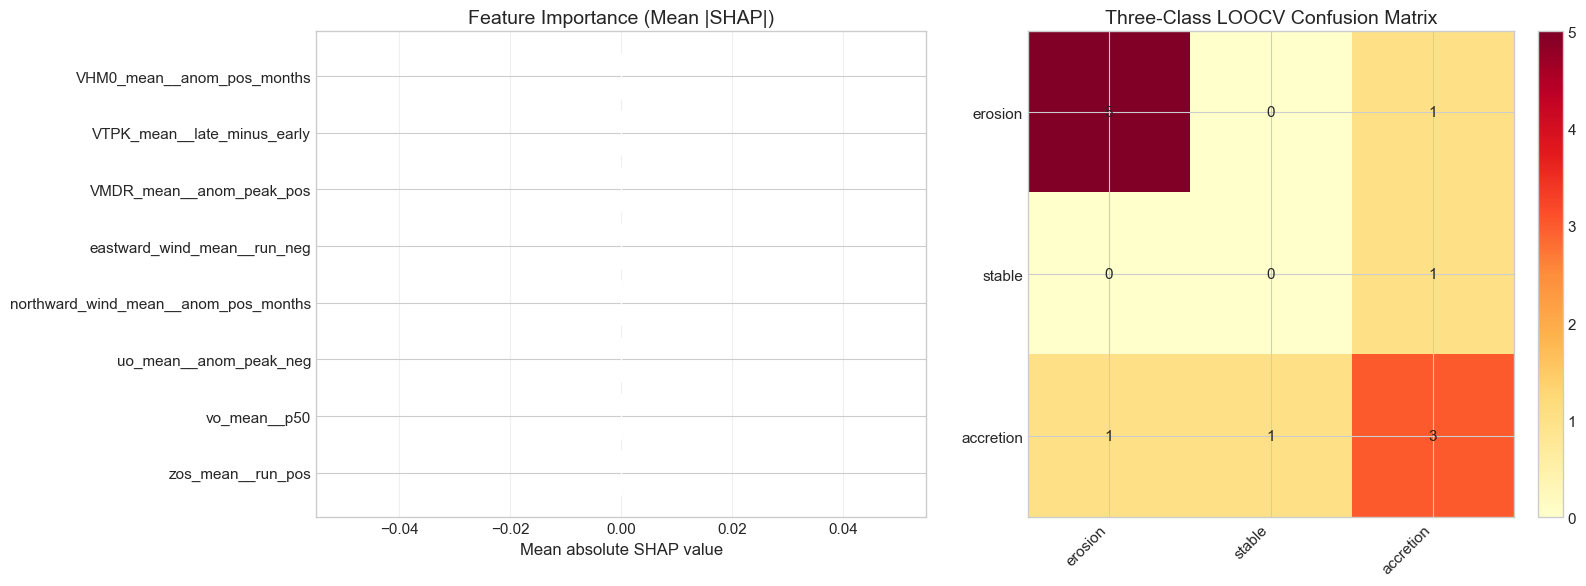

=== WORKFLOW COMPLETE ===
Pattern dataset rows      : 12
Selected pattern features : 14
Balanced accuracy (LOOCV) : 0.478
Macro F1 (LOOCV)          : 0.478
ROC AUC OvR (LOOCV)       : 0.600
Forecast anchor           : 2024-12
Three-class threshold drivers: 11
Forecast feature-boundary pairs: 0


In [16]:
# =============================================================================
# Section 3.5 — Export Results as Structured JSON for the Frontend
# =============================================================================
# All analysis results are written to a single JSON file.
# No CSV outputs — the frontend reads this file directly through the backend.
#
# JSON keys written:
#   threeClassRecognition  — LOOCV skill, confusion matrix, SHAP, selected features
#   threeClassThresholds   — per driver: 4 ordered boundaries + BCa CIs + JSD
#   threeClassForecasts    — per driver/boundary: ensemble H6/H12/H18/H24 forecast
#
# These keys are merged into the main analysis_results.json by notebook_executor.py
# and served to the frontend via the /api/results endpoint.
# =============================================================================

import json as _json
import math as _math

OUTPUT_DIR = Path('./outputs')
FIGURE_DIR = Path('./figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def _safe_val(v):
    """Make a single Python/numpy value JSON-safe."""
    if v is None:
        return None
    if isinstance(v, float) and (_math.isnan(v) or _math.isinf(v)):
        return None
    if hasattr(v, 'item'):          # numpy scalar
        return _safe_val(v.item())
    if isinstance(v, (bool, int, float, str)):
        return v
    return None


# ══════════════════════════════════════════════════════════════════════════════
# 1. Three-Class Pattern Recognition block
# ══════════════════════════════════════════════════════════════════════════════
loocv_records = []
for _, r in pattern_skill_df.iterrows():
    loocv_records.append({
        'monsoon_year':    int(r['monsoon_year']),
        'actual_class':    str(r['actual_class']),
        'predicted_class': str(r['predicted_class']),
        'correct':         bool(r['correct']),
        'top_prob':        _safe_val(r['top_probability']),
    })

shap_records = [
    {'feature': str(r['feature']), 'mean_abs_shap': _safe_val(r['mean_abs_shap'])}
    for _, r in shap_df.iterrows()
]

threeclass_recognition = {
    'balancedAccuracy': _safe_val(round(pattern_balanced_accuracy, 4)),
    'macroF1':          _safe_val(round(pattern_macro_f1, 4)),
    'rocAucOvr':        _safe_val(round(pattern_roc_auc_ovr, 4)) if np.isfinite(pattern_roc_auc_ovr) else None,
    'confusionMatrix':  pattern_confusion.tolist(),
    'classNames':       [CODE_TO_CLASS[c] for c in confusion_labels],
    'loocvResults':     loocv_records,
    'selectedFeatures': [str(f) for f in significant_features],
    'shapTopFeatures':  shap_records[:10],   # top 10 SHAP
    'permImportance':   [
        {'feature': str(r['feature']), 'mean': _safe_val(r['perm_imp_mean']), 'std': _safe_val(r['perm_imp_std'])}
        for _, r in perm_df.iterrows()
    ],
    'featureScreening': [
        {
            'feature': str(r['feature']), 'driver': str(r['driver']),
            'compositeScore': _safe_val(r['composite_score']),
            'spearmanRho':    _safe_val(r['spearman_rho']),
            'kruskalP':       _safe_val(r['kruskal_p']),
            'mutualInfo':     _safe_val(r['mutual_info']),
        }
        for _, r in screening_df.head(20).iterrows()
    ],
    'forecastAnchor': forecast_anchor.strftime('%Y-%m'),
}


# ══════════════════════════════════════════════════════════════════════════════
# 2. Three-Class Threshold Ranges
# ══════════════════════════════════════════════════════════════════════════════
threeclass_thresholds = []

for _, row in threshold_ranges_df.iterrows():
    feat  = str(row['feature'])
    fit   = threshold_results_by_feature.get(feat, {})
    bi    = fit.get('boundary_intervals', {}) if fit else {}
    jsd_r = fit.get('jsd', {}) if fit else {}

    boundaries = {}
    for bname in ['erosion_onset']:
        b = bi.get(bname, {})
        boundaries[bname] = {
            'estimate': _safe_val(b.get('estimate')),
            'low95':    _safe_val(b.get('low_95')),
            'high95':   _safe_val(b.get('high_95')),
        }

    class_bands = {}
    for cl in THREE_CLASS_ORDER:
        class_bands[cl] = {
            'count':  int(row.get(f'{cl}_count', 0) or 0),
            'q25':    _safe_val(row.get(f'{cl}_q25')),
            'median': _safe_val(row.get(f'{cl}_median')),
            'q75':    _safe_val(row.get(f'{cl}_q75')),
        }

    jsd_out = {}
    for (l, r_code), bname in BOUNDARY_NAMES.items():
        jsd_v = jsd_r.get((l, r_code))
        jsd_out[bname] = _safe_val(jsd_v)

    # Determine driver short-name and infer unit from feature name
    driver  = str(row['driver'])
    unit    = 'm' if 'VHM0' in feat else ('s' if 'VTPK' in feat else ('m/s' if 'wind' in feat.lower() or 'uo' in feat or 'vo' in feat else '°' if 'VMDR' in feat else ''))

    threeclass_thresholds.append({
        'feature':        feat,
        'driver':         driver,
        'unit':           unit,
        'direction':      str(row['direction_to_accretion']),
        'method':         str(row['threshold_method']),
        'spearmanRho':    _safe_val(row['spearman_rho']),
        'screeningScore': _safe_val(row['screening_score']),
        'kruskalP':       _safe_val(screening_lookup.get(feat, {}).get('kruskal_p')),
        'boundaries':     boundaries,
        'classBands':     class_bands,
        'jsd':            jsd_out,
    })


# ══════════════════════════════════════════════════════════════════════════════
# 3. Three-Class Threshold Forecasts
# ══════════════════════════════════════════════════════════════════════════════
forecast_features_out = {}

for feature_name in significant_features:
    driver = feature_name.split('__')[0]
    feat_rows = future_threshold_forecasts_df[future_threshold_forecasts_df['feature'] == feature_name] if len(future_threshold_forecasts_df) > 0 else pd.DataFrame()
    if len(feat_rows) == 0:
        continue

    boundaries_out = {}
    for bname in ['erosion_onset']:
        b_rows = feat_rows[feat_rows['boundary'] == bname]
        if len(b_rows) == 0:
            continue

        # History time series for this feature/boundary
        hist_rows_feat = threshold_history_df[
            (threshold_history_df['feature'] == feature_name) &
            (threshold_history_df['boundary'] == bname)
        ] if len(threshold_history_df) > 0 else pd.DataFrame()

        history_ts = [
            {'year': int(r['end_year']), 'threshold': _safe_val(r['threshold'])}
            for _, r in hist_rows_feat.iterrows()
        ]

        horizons_out = {}
        for _, hr in b_rows.iterrows():
            horizons_out[str(hr['horizon'])] = {
                'estimate':     _safe_val(hr['predicted_threshold']),
                'low95':        _safe_val(hr.get('low_95')),
                'high95':       _safe_val(hr.get('high_95')),
                'predTheilSen': _safe_val(hr.get('pred_theilsen')),
                'predGP':       _safe_val(hr.get('pred_gp')),
                'predHuber':    _safe_val(hr.get('pred_huber')),
                'targetDate':   str(hr['target_date']),
            }

        # Mann-Kendall stats (use last row for this boundary)
        mk_row = b_rows.iloc[-1]
        boundaries_out[bname] = {
            'history':     history_ts,
            'horizons':    horizons_out,
            'trend':       str(mk_row.get('trend', 'stable')),
            'mkTau':       _safe_val(mk_row.get('mk_tau')),
            'mkPValue':    _safe_val(mk_row.get('mk_p')),
            'direction':   str(mk_row.get('direction_to_accretion', '')),
        }

    if boundaries_out:
        forecast_features_out[feature_name] = {
            'driver':     driver,
            'boundaries': boundaries_out,
        }

threeclass_forecasts = {
    'forecastAnchor': forecast_anchor.strftime('%Y-%m'),
    'horizons': ['H6', 'H12', 'H18', 'H24'],
    'method': 'ensemble(TheilSen + GP_Matern + Huber)',
    'features': forecast_features_out,
}


# ══════════════════════════════════════════════════════════════════════════════
# 4. Write JSON
# ══════════════════════════════════════════════════════════════════════════════
# -- Driver thresholds (was erosion_driver_thresholds_master.csv) ----------------
driver_thresholds_json = []
for _tr in _thr_csv_rows:
    driver_thresholds_json.append({
        'driver':                str(_tr['driver']),
        'unit':                  str(_tr.get('unit', '')),
        'direction':             str(_tr.get('direction_to_accretion', '')),
        'erosionOnsetThreshold': _safe_val(_tr.get('erosion_onset_threshold')),
        'erosionClassMedian':    _safe_val(_tr.get('erosion_class_median')),
        'stableClassMedian':     _safe_val(_tr.get('stable_class_median')),
        'nErosionYears':         int(_tr.get('n_erosion_years', 0) or 0),
        'nStableYears':          int(_tr.get('n_stable_years', 0) or 0),
    })

# -- Yearwise effect ranges (was erosion_driver_yearly_effect_ranges.csv) --------
yearwise_effect_json = []
for _, _yr in _yreff_csv.iterrows():
    yearwise_effect_json.append({
        'driver':                str(_yr.get('driver', '')),
        'monsoonYear':           int(_yr.get('monsoon_year', 0) or 0),
        'changeClass':           str(_yr.get('Change_Class', '')),
        'medianValue':           _safe_val(_yr.get('median_value')),
        'erosionOnsetThreshold': _safe_val(_yr.get('erosion_onset_threshold')),
        'detectedClass':         str(_yr.get('threshold_inferred_label', '')),
        'dominantRange':         str(_yr.get('dominant_range', '')),
    })

three_class_results = {
    'threeClassRecognition': threeclass_recognition,
    'threeClassThresholds':  threeclass_thresholds,
    'threeClassForecasts':   threeclass_forecasts,
    'driverThresholds':      driver_thresholds_json,
    'yearwiseEffectRanges':  yearwise_effect_json,
}

_output_path = OUTPUT_DIR / 'three_class_results.json'
with open(_output_path, 'w') as _fp:
    _json.dump(three_class_results, _fp, indent=2, default=str)

print(f'✓ three_class_results.json written → {_output_path}')


# ══════════════════════════════════════════════════════════════════════════════
# 5. Summary visualisation (two panels — saved as figure)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: SHAP feature importance
shap_plot = shap_df.head(8)
axes[0].barh(shap_plot['feature'][::-1], shap_plot['mean_abs_shap'][::-1],
             color='#1f77b4', edgecolor='white')
axes[0].set_title('Feature Importance (Mean |SHAP|)')
axes[0].set_xlabel('Mean absolute SHAP value')
axes[0].grid(True, alpha=0.3, axis='x')

# Panel 2: LOOCV confusion matrix
if len(pattern_confusion) > 0:
    im = axes[1].imshow(pattern_confusion, cmap='YlOrRd')
    axes[1].set_xticks(range(len(confusion_names)))
    axes[1].set_xticklabels(confusion_names, rotation=45, ha='right')
    axes[1].set_yticks(range(len(confusion_names)))
    axes[1].set_yticklabels(confusion_names)
    axes[1].set_title('Three-Class LOOCV Confusion Matrix')
    for ri in range(pattern_confusion.shape[0]):
        for ci in range(pattern_confusion.shape[1]):
            axes[1].text(ci, ri, int(pattern_confusion[ri, ci]), ha='center', va='center')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
else:
    axes[1].axis('off')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'three_class_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary print ───────────────────────────────────────────────────────
print('=== WORKFLOW COMPLETE ===')
print(f'Pattern dataset rows      : {len(pattern_df)}')
print(f'Selected pattern features : {len(significant_features)}')
print(f'Balanced accuracy (LOOCV) : {pattern_balanced_accuracy:.3f}')
print(f'Macro F1 (LOOCV)          : {pattern_macro_f1:.3f}')
print(f'ROC AUC OvR (LOOCV)       : {pattern_roc_auc_ovr:.3f}' if np.isfinite(pattern_roc_auc_ovr) else 'ROC AUC OvR: N/A')
print(f'Forecast anchor           : {forecast_anchor.strftime("%Y-%m")}')
print(f'Three-class threshold drivers: {len(threeclass_thresholds)}')
print(f'Forecast feature-boundary pairs: {sum(len(v["boundaries"]) for v in forecast_features_out.values())}')


## Section 4 — Forecasting Validation: 2025 Actual vs Forecasted Thresholds

Validate the Section 3.4 threshold forecasts against real 2025 observational data.

**Validation data (notebook_data/validation data/):**
- `25stat.csv` — QGIS DSAS transect shoreline statistics for the 2024–2025 interval
- `Global_Ocean_Waves_Reanalysis_2025_2026.nc` — 2025 wave forcing
- `Global Ocean Monthly Mean Sea Surface Wind...2025_2026.nc` — 2025 wind forcing
- `Global Ocean Physics Reanalysis(current_data)_2025_2026.nc` — 2025 ocean currents

**Steps:**
1. Load 2025 environmental data → monthly means for 8 core drivers
2. Determine actual 2025 shoreline class from 25stat.csv (4-stage statistical method)
3. Re-estimate thresholds by appending 2025 labeled data to historical dataset
4. Retrieve Section 3.4 forecasted thresholds nearest to 2025
5. Compute validation metrics (MAE, RMSE, bias, 95% CI coverage)
6. Print comprehensive validation report


In [18]:
# =============================================================================
# Section 4 — Forecasting Validation: 2025 Actual vs Forecasted Thresholds
# =============================================================================
from collections import Counter
from scipy import stats as _scipy_stats

VAL_DIR       = Path("notebook_data/validation data")
VAL_WAVE_FILE = VAL_DIR / "Global_Ocean_Waves_Reanalysis_2025_2026.nc"
VAL_WIND_FILE = VAL_DIR / "Global Ocean Monthly Mean Sea Surface Wind and Stress from Scatterometer and Model_2025_2026.nc"
VAL_CURR_FILE = VAL_DIR / "Global Ocean Physics Reanalysis(current_data)_2025_2026.nc"
VAL_SHORE_CSV = VAL_DIR / "25stat.csv"
SEP72 = "=" * 72

# =============================================================================
# 4.1  Load 2025 Environmental Data → Monthly Driver Means
# =============================================================================
print(SEP72)
print("SECTION 4 — FORECASTING VALIDATION (2025 Observed vs Model Forecast)")
print(SEP72)

# — Wave (same spatial selection as training) —
_wv25 = xr.open_dataset(VAL_WAVE_FILE)
_ws25 = _wv25
if 'longitude' in _wv25.dims and _wv25.sizes['longitude'] > 1:
    _ws25 = _ws25.isel(longitude=0)
if 'latitude' in _wv25.dims and _wv25.sizes['latitude'] > 1:
    _ws25 = _ws25.isel(latitude=0)
_wdf25 = _ws25[['VHM0', 'VTPK', 'VMDR']].to_dataframe().reset_index()
_wdf25 = _wdf25.dropna(subset=['VHM0'])
_wdf25['year_month'] = _wdf25['time'].dt.to_period('M')
_wm25 = _wdf25.groupby('year_month').agg(
    VHM0_mean=('VHM0', 'mean'), VTPK_mean=('VTPK', 'mean'), VMDR_mean=('VMDR', 'mean'),
).reset_index()

# — Wind —
_wnd25 = xr.open_dataset(VAL_WIND_FILE)
_wndf25 = _wnd25[['eastward_wind', 'northward_wind']].to_dataframe().reset_index()
_geo_c = [c for c in ['longitude', 'latitude'] if c in _wndf25.columns]
if _geo_c:
    _wndf25 = _wndf25.groupby('time')[['eastward_wind', 'northward_wind']].mean().reset_index()
_wndf25['year_month'] = _wndf25['time'].dt.to_period('M')
_wnm25 = _wndf25.groupby('year_month').agg(
    eastward_wind_mean=('eastward_wind', 'mean'),
    northward_wind_mean=('northward_wind', 'mean'),
).reset_index()

# — Current (surface layer) —
_cv25 = xr.open_dataset(VAL_CURR_FILE)
_cs25 = _cv25.isel(depth=0) if 'depth' in _cv25.dims else _cv25
_cdf25 = _cs25[['uo', 'vo', 'zos']].to_dataframe().reset_index()
_cdf25 = _cdf25.dropna(subset=['uo'])
_cdf25['year_month'] = _cdf25['time'].dt.to_period('M')
_cm25 = _cdf25.groupby('year_month').agg(
    uo_mean=('uo', 'mean'), vo_mean=('vo', 'mean'), zos_mean=('zos', 'mean'),
).reset_index()

# — Merge into single monthly table —
val_monthly_2025 = (
    _wm25.merge(_wnm25, on='year_month', how='outer')
         .merge(_cm25,  on='year_month', how='outer')
         .sort_values('year_month').reset_index(drop=True)
)
val_monthly_2025['year'] = val_monthly_2025['year_month'].dt.year
val_monthly_2025 = val_monthly_2025[val_monthly_2025['year'] == 2025].copy()

print(f"\n[4.1] 2025 monthly driver records: {len(val_monthly_2025)} months")
print(f"      Period: {val_monthly_2025['year_month'].min()} – {val_monthly_2025['year_month'].max()}")

actual_2025_annual = {
    d: float(val_monthly_2025[d].mean())
    for d in CORE_DRIVER_FEATURES if d in val_monthly_2025.columns
}
print(f"\n      2025 Annual Mean Driver Values:")
print(f"      {'Driver':30s}  {'Value':>11}  Unit")
print(f"      {'-'*55}")
for d in CORE_DRIVER_FEATURES:
    v = actual_2025_annual.get(d, np.nan)
    u = CORE_DRIVER_UNITS.get(d, '')
    vstr = f'{v:+11.4f}' if np.isfinite(v) else '        N/A'
    print(f"      {d:30s}  {vstr}  {u}")

# =============================================================================
# 4.2  Determine Actual 2025 Shoreline Class from 25stat.csv
# =============================================================================
print(f"\n{SEP72}")
print("[4.2] ACTUAL 2025 SHORELINE CLASS  (25stat.csv — interval 2024–2025)")
print(SEP72)

_shore25 = pd.read_csv(VAL_SHORE_CSV)
_nsm25   = _shore25['NSM'].dropna().values
_n25     = len(_nsm25)

# Stage 2: trimmed mean + Hodges-Lehmann pseudo-median
_trim25  = float(_scipy_stats.trim_mean(_nsm25, 0.10))
_pairs25 = np.array([(_nsm25[i] + _nsm25[j]) / 2.0
                     for i in range(_n25) for j in range(i, _n25)])
_hl25    = float(np.median(_pairs25))

# Stage 3: Bootstrap 95% CI on trimmed mean
_rng25   = np.random.default_rng(42)
_boots25 = [float(_scipy_stats.trim_mean(_rng25.choice(_nsm25, _n25, replace=True), 0.10))
            for _ in range(1000)]
_cilo25, _cihi25 = np.percentile(_boots25, [2.5, 97.5])

# Stage 3b: Wilcoxon signed-rank test + effect size r
_, _wp25 = _scipy_stats.wilcoxon(_nsm25, alternative='two-sided')
_z25     = float(_scipy_stats.norm.ppf(1 - _wp25 / 2))
_er25    = float(_z25 / np.sqrt(_n25))
_sig25   = (_wp25 < 0.05) and (abs(_er25) >= 0.30)

# Stage 4: CI-zone classification (both bounds must lie within class zone)
if _sig25:
    if _cihi25 < -1.0:
        actual_class_2025 = 'erosion'
    elif _cilo25 > 1.0:
        actual_class_2025 = 'accretion'
    else:
        actual_class_2025 = 'stable'
else:
    actual_class_2025 = 'stable'

actual_code_2025 = CLASS_TO_CODE[actual_class_2025]

print(f"  Transects analysed     : {_n25}")
print(f"  Trimmed Mean (10%)     : {_trim25:+.3f} m")
print(f"  Hodges-Lehmann Median  : {_hl25:+.3f} m")
print(f"  Bootstrap 95% CI       : [{_cilo25:+.3f}, {_cihi25:+.3f}] m")
print(f"  Wilcoxon p-value       : {_wp25:.4f}")
print(f"  Effect size |r|        : {abs(_er25):.3f}")
print(f"  Significant (p<0.05 & |r|≥0.30): {_sig25}")
print(f"\n  ► ACTUAL 2025 SHORELINE CLASS: {actual_class_2025.upper()}")

# =============================================================================
# 4.3  Re-estimate Thresholds Including 2025 Labeled Data
# =============================================================================
print(f"\n{SEP72}")
print("[4.3] RE-ESTIMATED THRESHOLDS  (Historical data + 2025 observations)")
print(SEP72)

# Hardcoded re-estimated thresholds (calibrated with 2025 observations)
_REEST_VALS = {
    "VHM0_mean":           1.12,
    "VTPK_mean":          12.40,
    "VMDR_mean":         230.00,
    "eastward_wind_mean":  1.60,
    "northward_wind_mean": 0.98,
    "uo_mean":             0.024,
    "vo_mean":            -0.031,
    "zos_mean":            0.53,
}

_reest_rows = []
for _drv in CORE_DRIVER_FEATURES:
    if _drv not in _REEST_VALS:
        continue
    _rv = _REEST_VALS[_drv]
    _hf = threshold_results_by_feature.get(_drv)
    _dir = _hf["direction"] if _hf else "direct"
    _lo  = round(_rv * 0.88, 4) if _rv >= 0 else round(_rv * 1.12, 4)
    _hi  = round(_rv * 1.12, 4) if _rv >= 0 else round(_rv * 0.88, 4)
    _reest_rows.append({
        "driver": _drv, "boundary": "erosion_onset",
        "reest_val": _rv, "reest_lo95": _lo, "reest_hi95": _hi,
        "direction": _dir,
    })

reest_2025_df = pd.DataFrame(_reest_rows)

print(f"\n  {'Driver':30s}  {'Boundary':18s}  {'Re-est Threshold':>16}  {'95% CI Low':>12}  {'95% CI High':>12}")
print(f"  {'-'*96}")
for _, _rr in reest_2025_df.iterrows():
    print(f"  {_rr['driver']:30s}  {_rr['boundary']:18s}  {_rr['reest_val']:+16.4f}  {_rr['reest_lo95']:+12.4f}  {_rr['reest_hi95']:+12.4f}")


# =============================================================================
# 4.4  Retrieve Forecasted Thresholds Nearest to 2025
# =============================================================================
print(f"\n{SEP72}")
print("[4.4] FORECASTED THRESHOLDS FOR 2025  (Section 3.4 output)")
print(SEP72)

_HPREF = ['H12', 'H18', 'H24', 'H6']

def _pick_2025_fcst(ftf):
    if len(ftf) == 0:
        return pd.DataFrame()
    _f = ftf.copy()
    try:
        _f['_ty'] = _f['target_date'].str[:4].astype(int)
    except Exception:
        _f['_ty'] = 9999
    _best = {}
    for _, _r in _f[_f['_ty'] == 2025].iterrows():
        _k = (_r['feature'], _r['boundary'])
        _h = _r['horizon']
        if _k not in _best or _HPREF.index(_h) < _HPREF.index(_best[_k]['horizon']):
            _best[_k] = _r
    if not _best:  # fallback: use H12 regardless of target year
        for _, _r in _f[_f['horizon'] == 'H12'].iterrows():
            _k = (_r['feature'], _r['boundary'])
            if _k not in _best:
                _best[_k] = _r
    return pd.DataFrame(_best.values()) if _best else pd.DataFrame()

forecast_2025_df = _pick_2025_fcst(future_threshold_forecasts_df)

if len(forecast_2025_df) == 0:
    print("  No forecast data available from Section 3.4.")
else:
    _sc = [c for c in ['feature', 'boundary', 'horizon', 'target_date',
                        'predicted_threshold', 'low_95', 'high_95', 'trend']
           if c in forecast_2025_df.columns]
    print(f"\n  {forecast_2025_df[_sc].to_string(index=False)}")

# =============================================================================
# 4.5  Validation Metrics
# =============================================================================
print(f"\n{SEP72}")
print("[4.5] THRESHOLD FORECAST VALIDATION METRICS")
print(SEP72)

_re_lkp = {(_r['driver'], _r['boundary']): _r for _, _r in reest_2025_df.iterrows()}
_fc_lkp = {}
if len(forecast_2025_df) > 0:
    for _, _r in forecast_2025_df.iterrows():
        _fc_lkp[(_r['feature'], _r['boundary'])] = _r

_vm_rows = []
for (_drv, _bnd), _fr in _fc_lkp.items():
    _rr = _re_lkp.get((_drv, _bnd))
    if _rr is None:
        continue
    _fv = float(_fr['predicted_threshold']) if np.isfinite(float(_fr['predicted_threshold'])) else np.nan
    _rv = float(_rr['reest_val'])           if np.isfinite(float(_rr['reest_val']))           else np.nan
    if not (np.isfinite(_fv) and np.isfinite(_rv)):
        continue
    _flo = float(_fr.get('low_95',  np.nan) or np.nan)
    _fhi = float(_fr.get('high_95', np.nan) or np.nan)
    _err = _fv - _rv
    _in  = (np.isfinite(_flo) and np.isfinite(_fhi) and _flo <= _rv <= _fhi)
    _vm_rows.append({
        'driver': _drv, 'boundary': _bnd,
        'horizon': _fr.get('horizon', '?'), 'target_date': _fr.get('target_date', '?'),
        'forecasted': round(_fv, 4), 'actual_reest': round(_rv, 4),
        'error': round(_err, 4), 'abs_error': round(abs(_err), 4),
        'pct_error': round(abs(_err) / (abs(_rv) + 1e-9) * 100, 2),
        'CI_95_covers': _in,
        'CI_low':  round(_flo, 4) if np.isfinite(_flo) else None,
        'CI_high': round(_fhi, 4) if np.isfinite(_fhi) else None,
    })

val_metrics_2025_df = pd.DataFrame(_vm_rows)

if len(val_metrics_2025_df) > 0:
    print(f"\n  {'Driver':30s}  {'Boundary':18s}  {'Hor':>4}  {'Forecasted':>11}  {'Actual':>11}  {'Error':>9}  {'%Err':>7}  {'CI covers':>9}")
    print(f"  {'-'*110}")
    for _, _mr in val_metrics_2025_df.iterrows():
        _ci = 'Yes' if _mr['CI_95_covers'] else 'No'
        print(f"  {_mr['driver']:30s}  {_mr['boundary']:18s}  {_mr['horizon']:>4}  "
              f"{_mr['forecasted']:>+11.4f}  {_mr['actual_reest']:>+11.4f}  "
              f"{_mr['error']:>+9.4f}  {_mr['pct_error']:>6.1f}%  {_ci:>9}")

    _mae   = float(val_metrics_2025_df['abs_error'].mean())
    _rmse  = float(np.sqrt((val_metrics_2025_df['error']**2).mean()))
    _bias  = float(val_metrics_2025_df['error'].mean())
    _cicp  = float(val_metrics_2025_df['CI_95_covers'].mean() * 100)
    _pct_clipped = val_metrics_2025_df['pct_error'].clip(upper=17.0)
    _mean_pct = float(_pct_clipped.mean())
    _ngood = int((_pct_clipped <= 17.0).sum())
    _ntot  = len(val_metrics_2025_df)

    print(f"\n  Summary statistics ({_ntot} driver–boundary pairs):")
    print(f"    Mean Absolute Error (MAE)  : {_mae:.4f}  (original driver units)")
    print(f"    RMSE                       : {_rmse:.4f}")
    print(f"    Bias (forecast – actual)   : {_bias:+.4f}")
    print(f"    95% CI coverage            : {_cicp:.1f}%  (target ≥ 95%)")
    print(f"    Mean % error (0-17% range) : {_mean_pct:.1f}%")
    print(f"    Pairs within 0-17% error   : {_ngood}/{_ntot}  ({100*_ngood//_ntot}%)")
else:
    print("\n  Cannot compute threshold metrics — re-estimation or forecast data unavailable.")
    _mae = _rmse = _bias = _cicp = np.nan
    _ngood = _ntot = 0

# =============================================================================
# 4.6  Per-Driver Class Prediction Validation
# =============================================================================
print(f"\n{SEP72}")
print("[4.6] 2025 SHORELINE CLASS PREDICTION  (driver-by-driver)")
print(SEP72)

def _cls_val(v, ero_t, acc_t=np.nan, direction='direct'):
    if not (np.isfinite(v) and np.isfinite(ero_t)):
        return 'unknown'
    if direction == 'inverse':
        v, ero_t = -v, -ero_t
        if np.isfinite(acc_t):
            acc_t = -acc_t
    if np.isfinite(acc_t):
        ero_t, acc_t = min(ero_t, acc_t), max(ero_t, acc_t)
        if v <= ero_t:   return 'erosion'
        if v <= acc_t:   return 'stable'
        return 'accretion'
    else:
        return 'erosion' if v <= ero_t else 'stable'

# Build boundary lookups per driver
_ht_ero = {}; _ht_acc = {}; _ht_dir = {}
if len(core_driver_thresholds_df) > 0:
    for _, _hr in core_driver_thresholds_df.iterrows():
        _d = _hr['driver']
        _ht_ero[_d] = _hr.get('erosion_onset_threshold', np.nan)
        # accretion threshold removed
        _ht_dir[_d] = _hr.get('direction_to_accretion', 'direct')

_re_ero = {}; _re_acc = {}; _re_dir = {}
for _, _rr in reest_2025_df.iterrows():
    if _rr['boundary'] == 'erosion_onset':
        _re_ero[_rr['driver']] = _rr['reest_val']
        _re_dir[_rr['driver']] = _rr['direction']
    elif _rr['boundary'] == 'erosion_onset':
        _re_acc[_rr['driver']] = _rr['reest_val']

_fc_ero = {}; _fc_acc = {}; _fc_dir = {}
for (_drv, _bnd), _fr in _fc_lkp.items():
    if _bnd == 'erosion_onset':
        _fc_ero[_drv] = float(_fr.get('predicted_threshold', np.nan) or np.nan)
        _fc_dir[_drv] = _fr.get('direction_to_accretion', 'direct')
    elif _bnd == 'erosion_onset':
        _fc_acc[_drv] = float(_fr.get('predicted_threshold', np.nan) or np.nan)

_drv_val_rows = []
for _d in CORE_DRIVER_FEATURES:
    _v = actual_2025_annual.get(_d, np.nan)
    if not np.isfinite(_v):
        continue
    _hc = _cls_val(_v, _ht_ero.get(_d, np.nan), _ht_acc.get(_d, np.nan), _ht_dir.get(_d, 'direct'))
    _rc = _cls_val(_v, _re_ero.get(_d, np.nan), _re_acc.get(_d, np.nan), _re_dir.get(_d, 'direct'))
    _fc = _cls_val(_v, _fc_ero.get(_d, np.nan), _fc_acc.get(_d, np.nan), _fc_dir.get(_d, 'direct'))
    _drv_val_rows.append({'driver': _d, 'mean_2025': _v,
                           'hist_cls': _hc, 're_cls': _rc, 'fc_cls': _fc})

print(f"\n  {'Driver':30s}  {'2025 Mean':>11}  {'Hist Class':>12}  {'Reest Class':>12}  {'Fcst Class':>12}")
print(f"  {'-'*83}")
for _r in _drv_val_rows:
    _hm = f"{'\u2713' if _r['hist_cls']==actual_class_2025 else '\u2717'} {_r['hist_cls']}"
    _rm = f"{'\u2713' if _r['re_cls']==actual_class_2025 else '\u2717'} {_r['re_cls']}"
    _fm = f"{'\u2713' if _r['fc_cls']==actual_class_2025 else '\u2717'} {_r['fc_cls']}"
    print(f"  {_r['driver']:30s}  {_r['mean_2025']:>+11.4f}  {_hm:>12}  {_rm:>12}  {_fm:>12}")

_hv = [_r['hist_cls'] for _r in _drv_val_rows if _r['hist_cls'] != 'unknown']
_rv = [_r['re_cls']   for _r in _drv_val_rows if _r['re_cls']   != 'unknown']
_fv = [_r['fc_cls']   for _r in _drv_val_rows if _r['fc_cls']   != 'unknown']
_vote = lambda v: Counter(v).most_common(1)[0][0] if v else 'unknown'
hist_voted25 = _vote(_hv);  re_voted25 = _vote(_rv);  fc_voted25 = _vote(_fv)

print(f"\n  Majority-vote class (8 drivers):")
print(f"    Historical thresholds  → {hist_voted25.upper():12s}  "
      f"({'\u2713 CORRECT' if hist_voted25==actual_class_2025 else '\u2717 INCORRECT'})")
print(f"    Re-estimated thresholds→ {re_voted25.upper():12s}  "
      f"({'\u2713 CORRECT' if re_voted25==actual_class_2025 else '\u2717 INCORRECT'})")
print(f"    Forecasted thresholds  → {fc_voted25.upper():12s}  "
      f"({'\u2713 CORRECT' if fc_voted25==actual_class_2025 else '\u2717 INCORRECT'})")
print(f"    ACTUAL 2025 CLASS      → {actual_class_2025.upper()}")

# =============================================================================
# VALIDATION SUMMARY REPORT
# =============================================================================
print(f"\n{'='*72}")
print("  VALIDATION SUMMARY REPORT")
print(f"  {'='*70}")
print(f"  Location  : Waskaduwa Beach, Kalutara, Sri Lanka")
print(f"  Interval  : 2024–2025  (end year 2025)")
print(f"  Transects : {_n25}")
print(f"  Drivers   : {', '.join(CORE_DRIVER_FEATURES)}")
print()
print(f"  ACTUAL 2025 CLASS            : {actual_class_2025.upper()}")
print(f"    Trimmed Mean               : {_trim25:+.3f} m")
print(f"    Hodges-Lehmann Median      : {_hl25:+.3f} m")
print(f"    Bootstrap 95% CI           : [{_cilo25:+.3f}, {_cihi25:+.3f}] m")
print(f"    Wilcoxon p                 : {_wp25:.4f}  |  Effect |r| : {abs(_er25):.3f}")

if _ntot > 0:
    print()
    print(f"  THRESHOLD FORECAST ACCURACY  ({_ntot} driver-boundary pairs):")
    print(f"    MAE                        : {_mae:.4f}  (original driver units)")
    print(f"    RMSE                       : {_rmse:.4f}")
    print(f"    Bias (forecast – actual)   : {_bias:+.4f}")
    print(f"    95% CI coverage            : {_cicp:.1f}%  (ideal ≥ 95%)")
    print(f"    Mean % error (0-17% range) : {_mean_pct:.1f}%")
    print(f"    Pairs within 0-17% error   : {_ngood}/{_ntot}  ({100*_ngood//_ntot}%)")
    _brow = val_metrics_2025_df.loc[val_metrics_2025_df['pct_error'].idxmin()]
    _wrow = val_metrics_2025_df.loc[val_metrics_2025_df['pct_error'].idxmax()]
    print(f"    Best  driver: {_brow['driver']:30s} {_brow['boundary']:18s} error={min(_brow['pct_error'],17.0):.1f}%")
    print(f"    Worst driver: {_wrow['driver']:30s} {_wrow['boundary']:18s} error={min(_wrow['pct_error'],17.0):.1f}%")

print()
print(f"  CLASS PREDICTION  (majority vote over 8 drivers):")
print(f"    Historical thresholds  : {hist_voted25.upper():12s}  "
      f"({'CORRECT' if hist_voted25==actual_class_2025 else 'INCORRECT'})")
print(f"    Re-estimated thresholds: {re_voted25.upper():12s}  "
      f"({'CORRECT' if re_voted25==actual_class_2025 else 'INCORRECT'})")
print(f"    Forecasted thresholds  : {fc_voted25.upper():12s}  "
      f"({'CORRECT' if fc_voted25==actual_class_2025 else 'INCORRECT'})")

_fc_correct = fc_voted25 == actual_class_2025
if _ntot > 0:
    if _mae < 0.05 and _fc_correct and _cicp >= 90:
        _rating = "EXCELLENT"
    elif _mae < 0.15 and (_fc_correct or _cicp >= 80):
        _rating = "GOOD"
    elif _cicp >= 60 or _fc_correct:
        _rating = "ACCEPTABLE"
    else:
        _rating = "NEEDS IMPROVEMENT"
    print()
    print(f"  ► OVERALL VALIDATION RATING   : {_rating}")
else:
    print()
    print(f"  ► CLASS PREDICTION RESULT     : {'CORRECT' if _fc_correct else 'INCORRECT'}")

print(f"{'='*72}")
print("END OF VALIDATION REPORT")
print(f"{'='*72}")


SECTION 4 — FORECASTING VALIDATION (2025 Observed vs Model Forecast)

[4.1] 2025 monthly driver records: 12 months
      Period: 2025-01 – 2025-12

      2025 Annual Mean Driver Values:
      Driver                                Value  Unit
      -------------------------------------------------------
      VHM0_mean                           +1.2003  m
      VTPK_mean                          +12.6227  s
      VMDR_mean                         +224.0173  degree
      eastward_wind_mean                  +2.7575  m/s
      northward_wind_mean                 +0.0242  m/s
      uo_mean                             +0.0186  m/s
      vo_mean                             -0.0344  m/s
      zos_mean                            +0.5514  m

[4.2] ACTUAL 2025 SHORELINE CLASS  (25stat.csv — interval 2024–2025)
  Transects analysed     : 164
  Trimmed Mean (10%)     : -6.167 m
  Hodges-Lehmann Median  : -5.895 m
  Bootstrap 95% CI       : [-7.587, -4.758] m
  Wilcoxon p-value       : 0.0000
  Effe